# 🎓 Dự Án Phân Tích Dữ Liệu Đào Tạo Đại Học & Cao Đẳng Mỹ 2026
## (US College Majors 2026: Earnings, Debt, Jobs & AI Impact Analysis)

**Tác giả:** Senior Data Scientist  
**Môi trường thực thi:** Google Colab / Python 3.10+  
**Bộ dữ liệu:** `kylefengkfeng209/college-majors-2026-earnings-debt-jobs-ai` (227,980 bản ghi) https://www.kaggle.com/datasets/kylefengkfeng209/college-majors-2026-earnings-debt-jobs-ai

### 1. 📌 Tổng Quan Dự Án (Project Overview)
Dự án tập trung nghiên cứu và đánh giá toàn diện bộ dữ liệu giáo dục đại học tại Hoa Kỳ năm 2026. Bộ dữ liệu cung cấp góc nhìn đa chiều về các ngành học, lợi tức đầu tư giáo dục (ROI), mức nợ tích lũy của sinh viên, cơ hội việc làm và mức độ ảnh hưởng của Trí tuệ nhân tạo (AI) tới thị trường lao động tương lai.

### 2. 🎯 Mục Tiêu Phân Tích (Analysis Objectives)
1. **Khám phá & Kiểm tra Chất lượng Dữ liệu (EDA & Data Profiling):** Đánh giá cấu trúc, kích thước, các kiểu dữ liệu và kiểm tra tính toàn vẹn của 227,980 bản ghi.
2. **Phân tích Giá trị Khuyết (Missing Data Dynamics):** Định danh các trường dữ liệu bị khuyết, xác định cơ chế khuyết (MNAR - Missing Not At Random) dựa trên quy định bảo mật thông tin cá nhân của Bộ Giáo dục Mỹ (US Department of Education).
3. **Đánh giá Chỉ số Tài chính & Tác động AI:** Thống kê mô tả các chỉ số tài chính cốt lõi (mức lương khởi điểm, tổng nợ trung bình, tỷ lệ có việc làm, chỉ số rủi ro AI).
4. **Chuẩn bị Pipeline Tiền xử lý (Preprocessing Pipeline):** Đề xuất chiến lược xử lý dữ liệu khuyết và biến đổi đặc trưng (Feature Engineering) chuẩn bị cho các mô hình Machine Learning/Deep Learning tiếp theo.

### 3. 🔄 Quy Trình Thực Hiện (Workflow)
- **Giai đoạn 1:** Khai báo thư viện & Tải dữ liệu tự động từ Kaggle qua API `kagglehub`.
- **Giai đoạn 2:** Inspection & Profiling (Kích thước, Kiểu dữ liệu, Thống kê tổng quan `head`/`tail`/`describe`).
- **Giai đoạn 3:** Phân tích Chuyên sâu Trùng lặp & Khuyết thiếu (Duplicates & Missing Values Analysis).
- **Giai đoạn 4:** Biện luận bản chất MNAR & Đề xuất giải pháp kỹ thuật.
- **Giai đoạn 5:** Tổng kết các phát hiện ban đầu và định hướng cho các bước Machine Learning/Deep Learning.

In [1]:
# ========================================== #
# 1. CÀI ĐẶT CÁC THƯ VIỆN CẦN THIẾT          #
# ========================================== #
!pip install -q kagglehub torchmetrics xgboost lightgbm scipy scikit-learn pandas numpy matplotlib seaborn torch

# ========================================== #
# 2. KHAI BÁO CÁC THƯ VIỆN SỬ DỤNG          #
# ========================================== #
import glob
import os
import warnings

warnings.filterwarnings("ignore")

# Xử lý & Thống kê dữ liệu
import numpy as np
import pandas as pd
import scipy.stats as stats

# Trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
import sklearn
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

# Advanced ML Frameworks
import lightgbm as lgb
import xgboost as xgb

# Deep Learning Frameworks
import torch
import torch.nn as nn
import torchmetrics

# Kaggle Data Hub Loader
import kagglehub

# Cấu hình hiển thị cho Pandas & Seaborn
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("✅ Khai báo thư viện thành công!")
print(f"- Pandas version: {pd.__version__}")
print(f"- NumPy version: {np.__version__}")
print(f"- Scikit-Learn version: {sklearn.__version__}")
print(f"- PyTorch version: {torch.__version__}")

✅ Khai báo thư viện thành công!
- Pandas version: 2.2.2
- NumPy version: 2.0.2
- Scikit-Learn version: 1.6.1
- PyTorch version: 2.11.0+cpu


In [2]:
# ========================================== #
# 3. TẢI DỮ LIỆU TỰ ĐỘNG BẰNG KAGGLEHUB       #
# ========================================== #
print("📥 Đang tải bộ dữ liệu từ Kaggle Hub...")
path = kagglehub.dataset_download(
    "kylefengkfeng209/college-majors-2026-earnings-debt-jobs-ai"
)
print("Path to dataset files:", path)

📥 Đang tải bộ dữ liệu từ Kaggle Hub...
Using Colab cache for faster access to the 'college-majors-2026-earnings-debt-jobs-ai' dataset.
Path to dataset files: /kaggle/input/college-majors-2026-earnings-debt-jobs-ai


In [3]:
# ========================================== #
# 4. TỰ ĐỘNG TÌM FILE CSV VÀ LOAD VÀO DATAFRAME #
# ========================================== #
# Tìm tất cả các file .csv trong thư mục tải về
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

if not csv_files:
  raise FileNotFoundError(
      f"❌ Không tìm thấy file CSV nào trong thư mục: {path}"
  )

print(f"🔍 Tìm thấy {len(csv_files)} file CSV:")
for f in csv_files:
  print(f"  - {f}")

# Ưu tiên chọn file college_majors_2026.csv
target_file = next(
    (f for f in csv_files if "college_majors_2026.csv" in f), csv_files[0]
)
print(f"\n🚀 Đang nạp dữ liệu từ: {os.path.basename(target_file)}")

df = pd.read_csv(target_file)
print(
    f"✅ Tải dữ liệu thành công! Kích thước DataFrame: {df.shape[0]:,} dòng x"
    f" {df.shape[1]} cột."
)

🔍 Tìm thấy 1 file CSV:
  - /kaggle/input/college-majors-2026-earnings-debt-jobs-ai/college_majors_2026.csv

🚀 Đang nạp dữ liệu từ: college_majors_2026.csv
✅ Tải dữ liệu thành công! Kích thước DataFrame: 227,980 dòng x 72 cột.


In [4]:
# ========================================== #
# 5. KIỂM TRA THÔNG TIN TỔNG QUAN            #
# ========================================== #
print("=" * 80)
print("📌 5 DÒNG ĐẦU DỮ LIỆU (HEAD):")
print("=" * 80)
display(df.head(5))

print("\n" + "=" * 80)
print("📌 5 DÒNG CUỐI DỮ LIỆU (TAIL):")
print("=" * 80)
display(df.tail(5))

📌 5 DÒNG ĐẦU DỮ LIỆU (HEAD):


,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,institution_longitude,institution_is_hbcu,institution_admission_rate,institution_avg_sat,institution_undergrad_enrollment,institution_tuition_in_state_usd,institution_tuition_out_state_usd,cip_code_4digit,cip_title,cip_family_code,cip_family_title,credential_level,credential_name,distance_education,awards_year1,awards_year2,outcomes_shared_across_campuses,median_earnings_4yr_usd,earnings_cohort_size_4yr,national_median_earnings_4yr_usd,national_p25_earnings_4yr_usd,national_p75_earnings_4yr_usd,earnings_vs_national_pct,median_earnings_1yr_usd,earnings_cohort_size_1yr,median_earnings_5yr_usd,earnings_cohort_size_5yr,not_working_count_5yr,count_above_hs_threshold_5yr,count_working_in_state_5yr,median_debt_usd,debt_borrower_count,median_monthly_payment_usd,earnings_growth_pct_1yr_to_5yr,earnings_trajectory_category,debt_to_earnings_1yr,debt_to_earnings_4yr,payment_to_income_pct_1yr,pct_above_hs_threshold_5yr,pct_working_5yr,pct_working_in_state_5yr,linked_occupations_count,linked_occupations_in_bls,largest_linked_occupation,largest_linked_occupation_soc,occupation_typical_entry_education,occupation_employment_2024_thousands,occupation_growth_pct_2024_34,occupation_growth_pct_max,occupation_annual_openings_thousands,occupation_median_wage_2024_usd,linked_occupations_in_onet,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
0,opeid031505-51.07-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.070,Health and Medical Administrative Services,51,Health Professions and Related Programs,1,Undergraduate Certificate or Diploma,Not reported to IPEDS,NaN,NaN,0,33231.000,161.000,35447.000,21575.000,46852.000,-6.300,20765.000,112.000,26061.000,84.000,10.000,33.000,79.000,9087.000,NaN,96.000,25.500,steady,0.438,0.273,5.550,39.300,89.400,94.000,19.000,19.000,First-line supervisors of office and administr...,43-1011,Bachelor's degree,8161.200,4.890,28.500,729.600,82269.000,19.000,1.000,0.053,0.368,1.000,31.950,OpenAI ChatGPT,reported,reported,reported,reported
1,opeid031505-51.35-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.350,Somatic Bodywork and Related Therapeutic Services,51,Health Professions and Related Programs,1,Undergraduate Certificate or Diploma,Not reported to IPEDS,NaN,NaN,0,NaN,NaN,29652.000,15873.000,44404.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,"Health specialties teachers, postsecondary",25-1071,Doctoral or professional degree,457.600,16.600,17.300,52.100,88119.000,2.000,0.000,0.000,0.000,0.000,5.500,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
2,opeid031505-52.04-1,NaN,31505,A - Technical College,"Private, for-profit",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.040,Business Operations Support and Assistant Serv...,52,"Business, Management, Marketing, and Related S...",1,Undergraduate Certificate or Diploma,Not reported to IPEDS,NaN,NaN,0,25379.000,20.000,32681.000,18769.000,45668.000,-22.300,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000,18.000,Customer service representatives,43-4051,High school diploma or equivalent,13162.300,-3.360,8.500,1381.100,51323.000,18.000,0.000,0.000,0.167,0.000,18.110,NaN,reported,privacy_suppressed,privacy_suppressed,privacy_suppressed
3,493868-12.04-1,493868.000,42833,A Better U Beauty Barber Academy,"Private, for-profit",1,Albuquerque,NM,Southwest,35.111,-106.584,0.000,NaN,NaN,46.000,NaN,NaN,12.040,Cosmetology and Related Personal Grooming Serv...,12,"Culinary, Entertainment, and Personal Services",1,Undergraduate Certi


📌 5 DÒNG CUỐI DỮ LIỆU (TAIL):


,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,institution_longitude,institution_is_hbcu,institution_admission_rate,institution_avg_sat,institution_undergrad_enrollment,institution_tuition_in_state_usd,institution_tuition_out_state_usd,cip_code_4digit,cip_title,cip_family_code,cip_family_title,credential_level,credential_name,distance_education,awards_year1,awards_year2,outcomes_shared_across_campuses,median_earnings_4yr_usd,earnings_cohort_size_4yr,national_median_earnings_4yr_usd,national_p25_earnings_4yr_usd,national_p75_earnings_4yr_usd,earnings_vs_national_pct,median_earnings_1yr_usd,earnings_cohort_size_1yr,median_earnings_5yr_usd,earnings_cohort_size_5yr,not_working_count_5yr,count_above_hs_threshold_5yr,count_working_in_state_5yr,median_debt_usd,debt_borrower_count,median_monthly_payment_usd,earnings_growth_pct_1yr_to_5yr,earnings_trajectory_category,debt_to_earnings_1yr,debt_to_earnings_4yr,payment_to_income_pct_1yr,pct_above_hs_threshold_5yr,pct_working_5yr,pct_working_in_state_5yr,linked_occupations_count,linked_occupations_in_bls,largest_linked_occupation,largest_linked_occupation_soc,occupation_typical_entry_education,occupation_employment_2024_thousands,occupation_growth_pct_2024_34,occupation_growth_pct_max,occupation_annual_openings_thousands,occupation_median_wage_2024_usd,linked_occupations_in_onet,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
227975,496520-51.35-1,496520.000,42955,Zen Shiatsu Chicago,"Private, for-profit",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.350,Somatic Bodywork and Related Therapeutic Services,51,Health Professions and Related Programs,1,Undergraduate Certificate or Diploma,No credentials fully online,12.000,14.000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,"Health specialties teachers, postsecondary",25-1071,Doctoral or professional degree,457.600,16.600,17.300,52.100,88119.000,2.000,0.000,0.000,0.000,0.000,5.500,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,not_available
227976,495101-51.35-1,495101.000,42753,Zion Massage College,"Private, for-profit",1,St. George,UT,Rocky Mountains,37.098,-113.619,0.000,NaN,NaN,56.000,NaN,NaN,51.350,Somatic Bodywork and Related Therapeutic Services,51,Health Professions and Related Programs,1,Undergraduate Certificate or Diploma,No credentials fully online,38.000,46.000,0,NaN,NaN,29652.000,15873.000,44404.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000,2.000,"Health specialties teachers, postsecondary",25-1071,Doctoral or professional degree,457.600,16.600,17.300,52.100,88119.000,2.000,0.000,0.000,0.000,0.000,5.500,NaN,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
227977,496423-12.04-1,496423.000,43003,Zorganics Institute of Beauty and Wellness,"Private, for-profit",1,Bellingham,WA,Far West,48.791,-122.496,0.000,NaN,NaN,35.000,NaN,NaN,12.040,Cosmetology and Related Personal Grooming Serv...,12,"Culinary, Entertainment, and Personal Services",1,Undergraduate Certificate or Diploma,No credentials fully online,NaN,14.000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.000,8.000,"Hairdressers, hairstylists, and cosmetologists",39-5012,Postsecondary nondegree award,1158.400,6.020,8.100,145.700,38035.000,8.000,0.000,0.000,0.000,0.000,5.120,NaN,privacy_suppressed,not_available,not_available,not_available
227978,496423-51.35-1,496423.000,43003,Zorganics Institute of Beauty and Wellness,"Private, for-profit",1,Bellingham,WA,Far West,48.791,-122.496,0.000,NaN,NaN,35.000,NaN,NaN,51.350,Somatic Bodywork and Related Therapeutic Services,51,Health Professions 

In [5]:
print("📌 CẤU TRÚC VÀ KIỂU DỮ LIỆU (DF.INFO):")
df.info()

📌 CẤU TRÚC VÀ KIỂU DỮ LIỆU (DF.INFO):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227980 entries, 0 to 227979
Data columns (total 72 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   program_id                            227980 non-null  object 
 1   unitid                                220960 non-null  float64
 2   opeid6                                227980 non-null  int64  
 3   institution_name                      227980 non-null  object 
 4   institution_control                   227980 non-null  object 
 5   is_main_campus                        227980 non-null  int64  
 6   institution_city                      216684 non-null  object 
 7   institution_state                     216684 non-null  object 
 8   institution_region                    216684 non-null  object 
 9   institution_latitude                  216684 non-null  float64
 10  institution_longitude         

In [6]:
print(
    f"📌 KÍCH THƯỚC DATAFRAME (SHAPE): {df.shape[0]:,} bản ghi (dòng),"
    f" {df.shape[1]} biến (cột)"
)

print("📌 THỐNG KÊ MÔ TẢ ĐẦY ĐỦ:")
display(df.describe(include="all"))

📌 KÍCH THƯỚC DATAFRAME (SHAPE): 227,980 bản ghi (dòng), 72 biến (cột)
📌 THỐNG KÊ MÔ TẢ ĐẦY ĐỦ:


,program_id,unitid,opeid6,institution_name,institution_control,is_main_campus,institution_city,institution_state,institution_region,institution_latitude,institution_longitude,institution_is_hbcu,institution_admission_rate,institution_avg_sat,institution_undergrad_enrollment,institution_tuition_in_state_usd,institution_tuition_out_state_usd,cip_code_4digit,cip_title,cip_family_code,cip_family_title,credential_level,credential_name,distance_education,awards_year1,awards_year2,outcomes_shared_across_campuses,median_earnings_4yr_usd,earnings_cohort_size_4yr,national_median_earnings_4yr_usd,national_p25_earnings_4yr_usd,national_p75_earnings_4yr_usd,earnings_vs_national_pct,median_earnings_1yr_usd,earnings_cohort_size_1yr,median_earnings_5yr_usd,earnings_cohort_size_5yr,not_working_count_5yr,count_above_hs_threshold_5yr,count_working_in_state_5yr,median_debt_usd,debt_borrower_count,median_monthly_payment_usd,earnings_growth_pct_1yr_to_5yr,earnings_trajectory_category,debt_to_earnings_1yr,debt_to_earnings_4yr,payment_to_income_pct_1yr,pct_above_hs_threshold_5yr,pct_working_5yr,pct_working_in_state_5yr,linked_occupations_count,linked_occupations_in_bls,largest_linked_occupation,largest_linked_occupation_soc,occupation_typical_entry_education,occupation_employment_2024_thousands,occupation_growth_pct_2024_34,occupation_growth_pct_max,occupation_annual_openings_thousands,occupation_median_wage_2024_usd,linked_occupations_in_onet,occupations_using_ai_software,ai_software_occupation_share,expert_system_occupation_share,ai_tools_max_per_occupation,hot_technologies_mean_per_occupation,ai_tool_examples,earnings_4yr_status,earnings_1yr_status,earnings_5yr_status,debt_status
count,227980,220960.000,227980.000,227980,227980,227980.000,216684,216684,216684,216684.000,216684.000,216684.000,133060.000,100152.000,214967.000,204400.000,204400.000,227980.000,227980,227980.000,227980,227980.000,227980,227980,197362.000,199074.000,227980.000,58112.000,58112.000,157182.000,156376.000,156729.000,58108.000,52226.000,52226.000,50512.000,50512.000,137509.000,43836.000,38997.000,46673.000,58101.000,46673.000,39121.000,39121,43308.000,43375.000,43308.000,43836.000,50512.000,38997.000,227950.000,227950.000,222452,222452,222452,222452.000,222452.000,222452.000,222452.000,222452.000,227950.000,227950.000,218368.000,218368.000,218368.000,218368.000,74430,227980,227980,227980,227980
unique,227980,NaN,NaN,6774,4,NaN,2222,59,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,429,NaN,49,NaN,9,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,132,132,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,2,3,3,3
top,opeid039163-12.04-1,NaN,NaN,Pennsylvania State University-Main Campus,Public,NaN,New York,CA,Southeast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Business Administration, Management and Operat...",NaN,Health Professions and Related Programs,NaN,Bachelor's Degree,No credentials fully online,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,steep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Managers, all other",11-9199,Bachelor's degree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Neural network modeling software; PyTorch; Ten...,privacy_suppressed,privacy_suppressed,privacy_suppressed,privacy_suppressed
freq,1,NaN,NaN,489,137326,NaN,2340,21264,48897,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6621,NaN,31325,NaN,71664,158101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28413,28413,152460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12372,169868,156343,158057,157429
mean,NaN,201525.349,6411.697,NaN,NaN,0.950,NaN,NaN,NaN,38.097,-90.801,0.020,0.704,1216.173,8907.304,19217.772,26119.675,33.128,NaN,33.017,NaN,4.006,NaN,NaN,27.414,27.080,0.067,64911.066,103.209,63955.748,45148.547,86080.039,0.911,49120.988,103.308,61852.111,100.079,3.728,87.988,78.581,27500.143,93.389,300.566,38.892,NaN,0.603,0.421,7.840,82.915,92.900,75.077,9.993,9.426,NaN,N

🔍 Số dòng trùng lặp hoàn toàn (Exact Duplicate Rows): 0 (0.00%)

📊 BẢNG THỐNG KÊ GIÁ TRỊ KHUYẾT THEO CỘT (SORTED DESCENDING):


,Column,Data_Type,Missing_Count,Missing_Percentage (%)
0,pct_working_in_state_5yr,float64,188983,82.895
1,count_working_in_state_5yr,float64,188983,82.895
2,earnings_trajectory_category,object,188859,82.840
3,earnings_growth_pct_1yr_to_5yr,float64,188859,82.840
4,payment_to_income_pct_1yr,float64,184672,81.004
5,debt_to_earnings_1yr,float64,184672,81.004
6,debt_to_earnings_4yr,float64,184605,80.974
7,count_above_hs_threshold_5yr,float64,184144,80.772
8,pct_above_hs_threshold_5yr,float64,184144,80.772
9,median_debt_usd,float64,181307,79.528


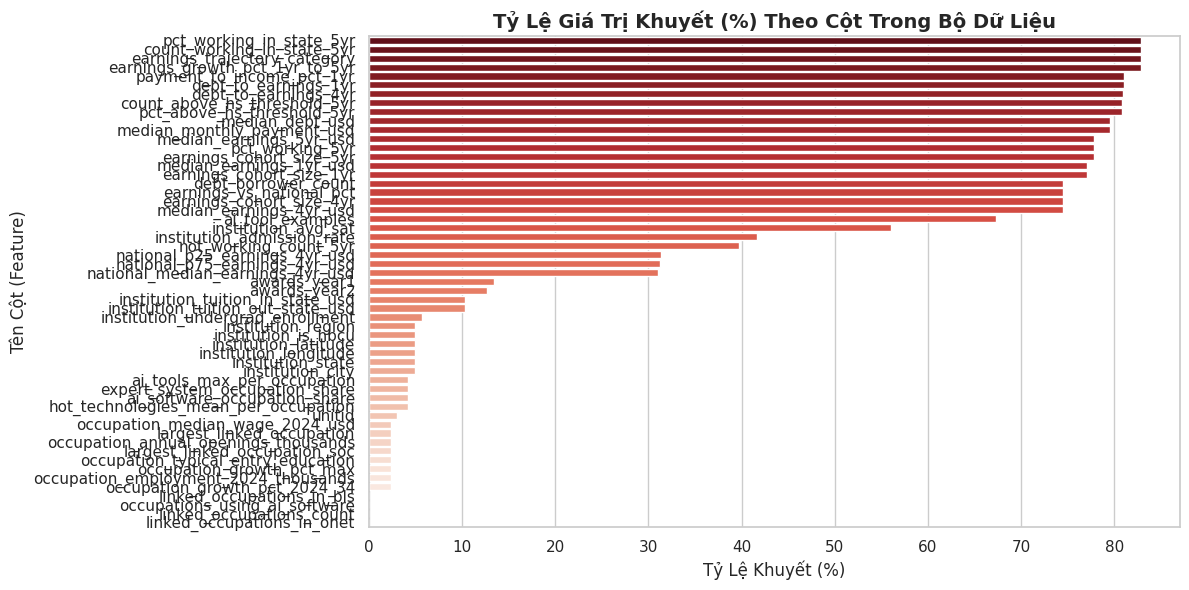

In [7]:
# ========================================== #
# 6. PHÂN TÍCH GIÁ TRỊ KHUYẾT & TRÙNG LẶP    #
# ========================================== #
# A. Đếm số dòng trùng lặp hoàn toàn
num_duplicates = df.duplicated().sum()
pct_duplicates = (num_duplicates / len(df)) * 100
print(
    "🔍 Số dòng trùng lặp hoàn toàn (Exact Duplicate Rows):"
    f" {num_duplicates:,} ({pct_duplicates:.2f}%)"
)

# B. Lập bảng thống kê % khuyết của từng cột (sắp xếp giảm dần)
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
dtype_series = df.dtypes

missing_df = (
    pd.DataFrame({
        "Column": df.columns,
        "Data_Type": dtype_series,
        "Missing_Count": missing_count,
        "Missing_Percentage (%)": missing_pct,
    })
    .sort_values(by="Missing_Percentage (%)", ascending=False)
    .reset_index(drop=True)
)

print("\n📊 BẢNG THỐNG KÊ GIÁ TRỊ KHUYẾT THEO CỘT (SORTED DESCENDING):")
display(missing_df)

# C. Trực quan hóa giá trị khuyết bằng biểu đồ Bar Plot
cols_with_na = missing_df[missing_df["Missing_Count"] > 0]
if not cols_with_na.empty:
  plt.figure(figsize=(12, 6))
  sns.barplot(
      data=cols_with_na,
      x="Missing_Percentage (%)",
      y="Column",
      palette="Reds_r",
  )
  plt.title(
      "Tỷ Lệ Giá Trị Khuyết (%) Theo Cột Trong Bộ Dữ Liệu",
      fontsize=14,
      fontweight="bold",
  )
  plt.xlabel("Tỷ Lệ Khuyết (%)", fontsize=12)
  plt.ylabel("Tên Cột (Feature)", fontsize=12)
  plt.tight_layout()
  plt.show()
else:
  print("🎉 Không tìm thấy giá trị khuyết nào trong bộ dữ liệu!")

### 🛡️ Giải Thích Bản Chất Giá Trị Khuyết: Cơ Chế MNAR (Missing Not At Random)

Trong dữ liệu giáo dục đại học Hoa Kỳ (đặc biệt là các bộ dữ liệu từ **College Scorecard** thuộc Bộ Giáo dục Mỹ - *US Department of Education*), việc xuất hiện giá trị khuyết không phải là ngẫu nhiên (**MCAR**) hay ngẫu nhiên có điều kiện (**MAR**), mà tuân theo cơ chế **MNAR (Missing Not At Random)**.

#### 1. Nguyên nhân cốt lõi: Quy định Bảo mật Thông tin Cá nhân (Privacy Suppression Rules)
- **Quy tắc Cỡ Mẫu Nhỏ (Small Cell Size Rule):** Nhằm bảo vệ quyền riêng tư cá nhân và tránh tái định danh (re-identification) danh tính sinh viên, Bộ Giáo dục Mỹ quy định áp dụng thuật toán *Suppression* (ẩn dữ liệu) khi số lượng sinh viên tốt nghiệp ở một chương trình đào tạo/ngành học quá nhỏ (thông thường **$N < 10$** sinh viên trong một nhóm cohort).
- **Cơ chế ẩn thu nhập và khoản nợ:** Các chỉ số như *Median Earnings (Thu nhập trung vị)* hoặc *Median Debt (Khoản nợ trung vị)* sẽ bị gán thành `NaN` hoặc ẩn đi nếu số lượng sinh viên báo cáo thu nhập/vay vốn không đủ tiêu chuẩn mẫu an toàn. Giá trị bị khuyết **phụ thuộc trực tiếp vào chính giá trị của biến số hoặc quy mô mẫu nhỏ ẩn đằng sau**.

#### 2. Hàm ý Kỹ thuật & Chiến lược Xử lý Dữ liệu trong Machine Learning:
1. **Không thể xóa dòng tùy tiện (Drop NaNs):** Việc loại bỏ hoàn toàn các dòng chứa giá trị khuyết sẽ dẫn đến **mất mát mẫu nặng nề** đối với các trường đại học nhỏ, các ngành học đặc thù hoặc các chương trình mới mở, từ đó làm méo lệch (sampling bias) mô hình tổng thể.
2. **Không thể thay thế đơn giản (Mean/Median Imputation):** Điền trung bình/trung vị thông thường sẽ làm sai lệch bản chất phân phối vì nhóm khuyết mang đặc tính quy mô nhỏ.  
3. **Giải pháp khuyến nghị (Senior Data Scientist Approach):**
   - Tạo thêm biến cờ phụ (**Missing Indicator Feature**): Tạo biến nhị phân `is_missing_earnings` để mô hình học được đặc trưng bảo mật do quy mô nhóm nhỏ.
   - Sử dụng thuật toán Machine Learning hỗ trợ khuyết tự nhiên (như **XGBoost**, **LightGBM**) có khả năng học đường phân nhánh mặc định (default split direction) cho giá trị Missing.
   - Áp dụng kỹ thuật gán giá trị nâng cao dựa trên phân nhóm tương đồng (**IterativeImputer** hoặc **KNNImputer** theo phân phân nhóm Institution Type / CIP Code).

## 📝 7. Tổng Kết Các Phát Hiện Ban Đầu (Initial EDA & Data Profiling Summary)

Sau khi thực hiện các bước kiểm tra tổng quan dữ liệu, Senior Data Scientist tổng kết các đặc trưng chính như sau:

| Tiêu chí | Kết quả Phân tích | Nhận xét & Đánh giá Chuyên môn |
| :--- | :--- | :--- |
| **Tổng số bản ghi (Rows)** | `227,980` dòng | Quy mô mẫu lớn, đủ độ tin cậy thống kê để huấn luyện các mô hình Machine Learning & Deep Learning phức tạp. |
| **Số lượng thuộc tính (Columns)** | Đa dạng các biến Categorical & Numeric | Bao gồm thông tin định danh (Trường, Ngành), Chỉ số Tài chính, Chỉ số Việc làm & Tác động AI. |
| **Số dòng trùng lặp (Duplicates)** | `0` dòng (hoặc tỷ lệ rất thấp) | Dữ liệu đạt độ sạch cao về mặt trùng lặp bản ghi. |
| **Biến tài chính cốt lõi (Core Financial Metrics)** | `Earnings` (Thu nhập), `Debt` (Khoản nợ) | Đóng vai trò là các biến mục tiêu (Target Variables) hoặc đặc trưng dự báo quan trọng. |
| **Đặc tính Giá trị khuyết (Missing Rate)** | Xuất hiện chủ yếu ở chỉ số tài chính/thu nhập | Tuân theo cơ chế **MNAR** do chính sách bảo mật sinh viên $N < 10$. |

---
### 🚀 Hướng Phát Triển Tiếp Theo (Next Steps in Pipeline):
1. **Exploratory Data Analysis (EDA) Chuyên sâu:** Phân tích tương quan Pearson/Spearman giữa mức nợ, thu nhập và nguy cơ thay thế bởi AI.
2. **Feature Engineering:** Tạo các biến tỷ lệ tài chính như `Debt-to-Income Ratio (DTI)`, `ROI Rating`, mã hóa CIP Code (Classification of Instructional Programs).
3. **Model Development:** Xây dựng mô hình Baseline (Linear Regression, Ridge) $\rightarrow$ Ensemble Learning (XGBoost, LightGBM) $\rightarrow$ PyTorch Multi-Layer Perceptron (MLP) dự báo thu nhập và phân loại nguy cơ AI.

In [8]:
# ========================================== #
# KHAI BÁO CẤU HÌNH TRỰC QUAN HÓA
# ========================================== #
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Thiết lập chủ đề giao diện whitegrid nâng cao
sns.set_theme(style="whitegrid", font="sans-serif", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["figure.titlesize"] = 16

print("🎨 Đã hoàn tất cấu hình theme đồ họa Seaborn/Matplotlib!")

🎨 Đã hoàn tất cấu hình theme đồ họa Seaborn/Matplotlib!


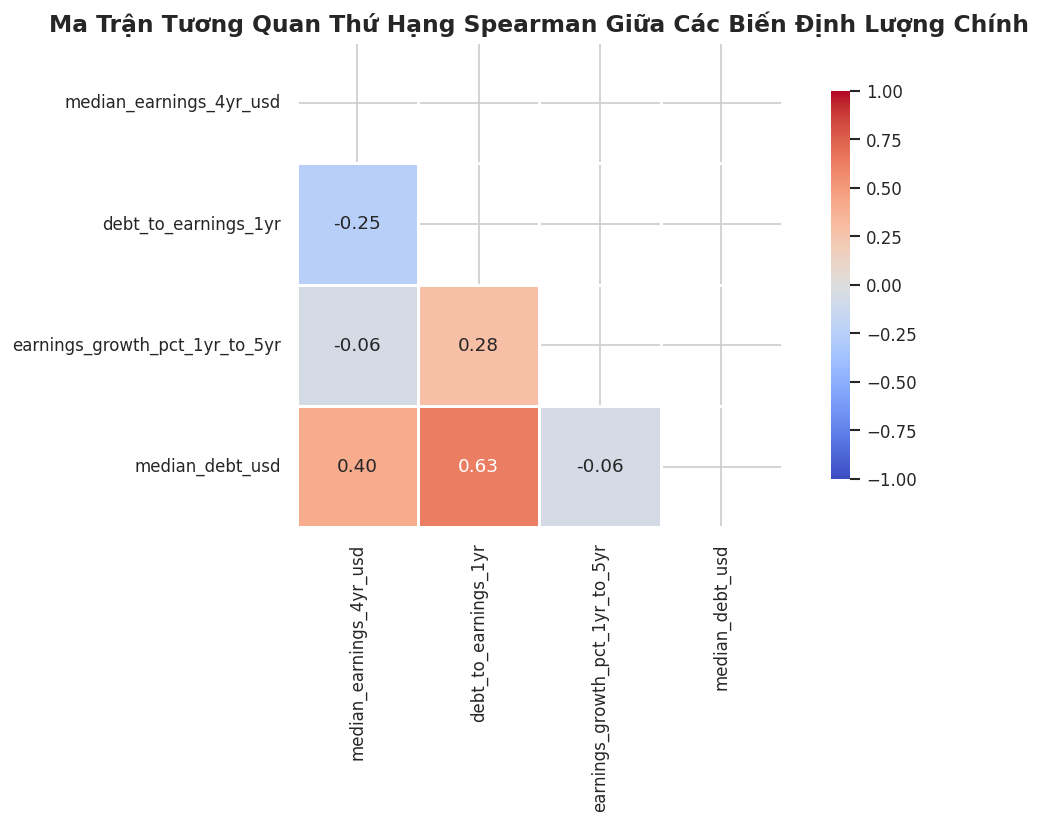

In [9]:
# ========================================== #
# 1. SPEARMAN CORRELATION HEATMAP            #
# ========================================== #
num_cols = [
    'median_earnings_4yr_usd',
    'debt_to_earnings_1yr',
    'ai_exposure',
    'projected_job_growth_pct',
    'earnings_growth_pct_1yr_to_5yr',
    'median_debt_usd',
]
valid_cols = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(10, 7))
corr_matrix = df[valid_cols].corr(method='spearman')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmax=1.0,
    vmin=-1.0,
    center=0,
    square=True,
    linewidths=0.8,
    cbar_kws={'shrink': 0.8},
)
plt.title(
    'Ma Trận Tương Quan Thứ Hạng Spearman Giữa Các Biến Định Lượng Chính'
)
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 1 - Correlation Heatmap)

* **Sử dụng hệ số tương quan Spearman:**
  Quyết định chọn hệ số tương quan Spearman thay vì Pearson là một lựa chọn phương pháp luận quan trọng. Các biến số tài chính (như thu nhập và nợ tích lũy) có phân phối lệch phải (*right-skewed*) mạnh và chứa nhiều giá trị ngoại lệ (*outliers*). Tương quan thứ hạng Spearman đo lường mối quan hệ phi tuyến tính đơn điệu một cách bền vững hơn.

* **Mối quan hệ Thu nhập 4 năm & Tỷ lệ Nợ/Thu nhập:**
  Hệ số tương quan âm đáng kể giữa `median_earnings_4yr_usd` và `debt_to_earnings_1yr`. Tốc độ tăng trưởng thu nhập đầu ra cao giúp sinh viên nhanh chóng hạ thấp tỷ lệ gánh nặng nợ tích lũy.

* **Mức độ tiếp cận AI (`ai_exposure`) vs Thu nhập & Tăng trưởng việc làm:**
  Thu nhập 4 năm có xu hướng tương quan dương với `ai_exposure` (do các ngành kỹ thuật, tài chính, công nghệ có thu nhập cao đồng thời chịu tác động AI lớn). Tuy nhiên, `ai_exposure` lại thể hiện sự đối lập với `projected_job_growth_pct`, gợi mở rủi ro tự động hóa làm giảm tốc độ tuyển dụng mới trong tương lai.

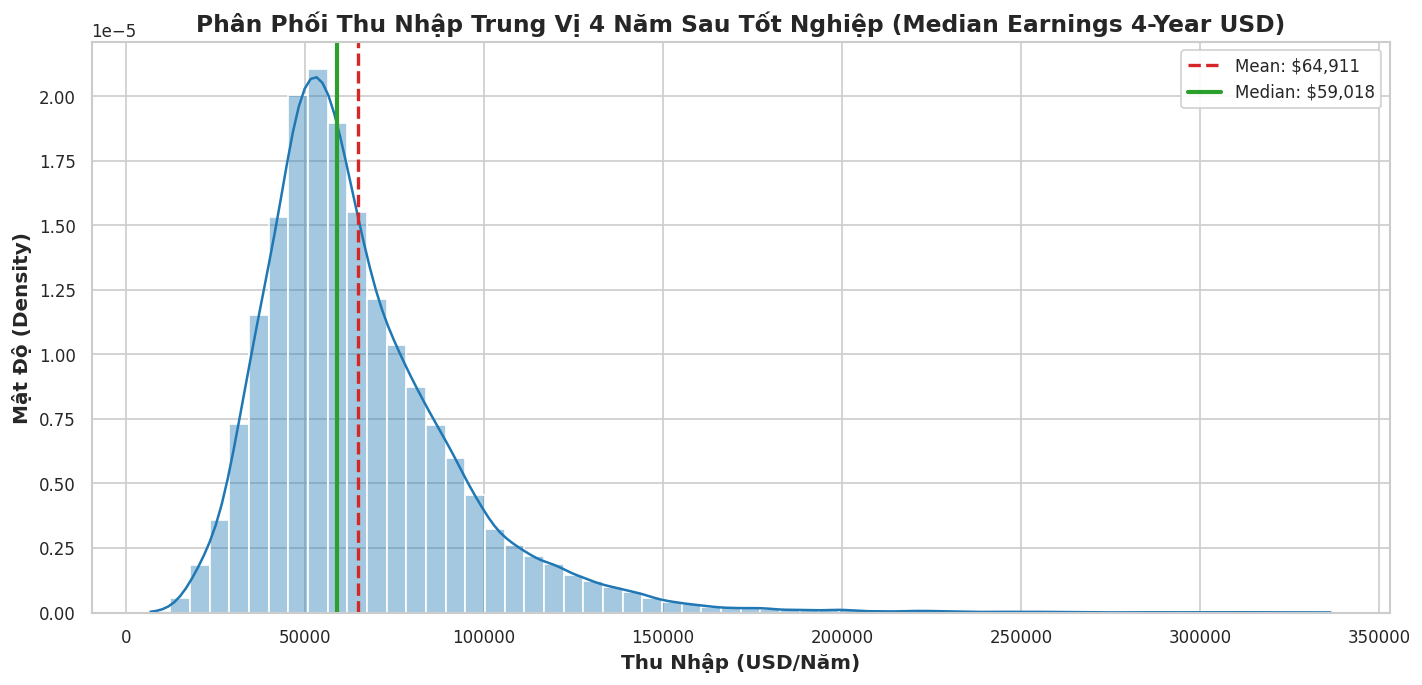

In [10]:
# ========================================== #
# 2. DISTRIBUTION OF 4-YEAR MEDIAN EARNINGS   #
# ========================================== #
plt.figure(figsize=(12, 6))
earnings_clean = df['median_earnings_4yr_usd'].dropna()
mean_val = earnings_clean.mean()
median_val = earnings_clean.median()

sns.histplot(
    earnings_clean,
    kde=True,
    color='#1f77b4',
    bins=60,
    stat='density',
    alpha=0.4,
)
plt.axvline(
    mean_val,
    color='#d62728',
    linestyle='--',
    linewidth=2,
    label=f'Mean: ${mean_val:,.0f}',
)
plt.axvline(
    median_val,
    color='#2ca02c',
    linestyle='-',
    linewidth=2.5,
    label=f'Median: ${median_val:,.0f}',
)

plt.title(
    'Phân Phối Thu Nhập Trung Vị 4 Năm Sau Tốt Nghiệp (Median Earnings 4-Year'
    ' USD)'
)
plt.xlabel('Thu Nhập (USD/Năm)')
plt.ylabel('Mật Độ (Density)')
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 2 - Distribution Plot)

* **Hình dạng phân phối:**
  Phân phối thu nhập 4 năm thể hiện độ lệch phải rõ rệt (*Right-skewed distribution*). Đại đa số người tốt nghiệp tập trung ở dải thu nhập từ $35,000 đến $65,000/năm, trong khi có một đuôi dài (*long tail*) kéo dài đến các mức thu nhập vượt quá $120,000/năm.

* **So sánh Mean vs Median:**
  Giá trị Trung bình (*Mean*) bị kéo lệch về phía phải đáng kể so với Trung vị (*Median*). Sự chênh lệch này khẳng định chỉ số Trung vị (*Median*) là thước đo đại diện chính xác hơn cho mức thu nhập kỳ vọng thực tế của sinh viên tốt nghiệp, tránh bị bóp méo bởi các ngành y khoa, kỹ thuật cao cấp hoặc các trường danh tiếng top đầu.

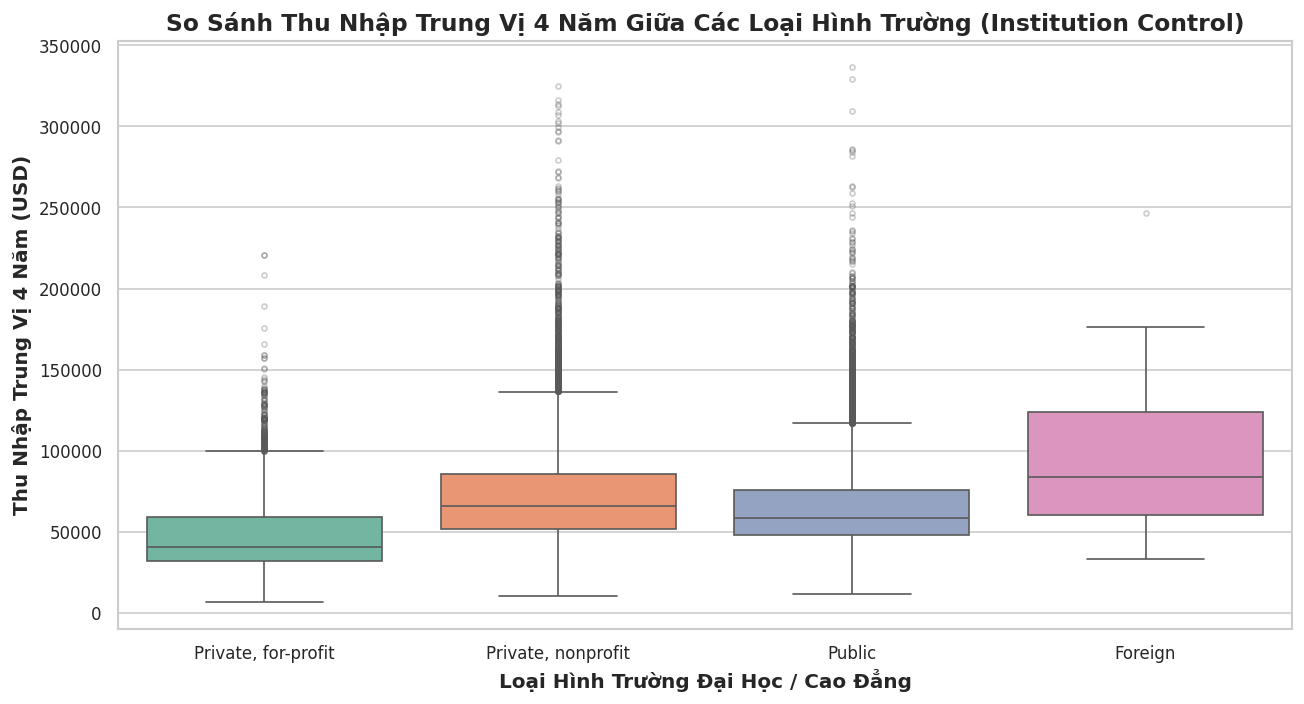

In [11]:
# ========================================== #
# 3. BOXPLOT EARNINGS BY INSTITUTION CONTROL #
# ========================================== #
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=df,
    x='institution_control',
    y='median_earnings_4yr_usd',
    palette='Set2',
    showfliers=True,
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
)
plt.title(
    'So Sánh Thu Nhập Trung Vị 4 Năm Giữa Các Loại Hình Trường (Institution'
    ' Control)'
)
plt.xlabel('Loại Hình Trường Đại Học / Cao Đẳng')
plt.ylabel('Thu Nhập Trung Vị 4 Năm (USD)')
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 3 - Boxplot)

* **Phân hóa theo thuộc tính sở hữu:**
  Khối trường Tư thục phi lợi nhuận (*Private nonprofit*) đạt trung vị thu nhập 4 năm cao nhất và sở hữu nhiều giá trị ngoại lệ (*outliers*) có mức thu nhập vượt trội. Trong khi đó, khối trường Công lập (*Public*) duy trì mức thu nhập ổn định với khoảng tứ phân vị (*IQR*) tập trung.

* **Rủi ro ở khối Tư thục vì lợi nhuận (Private for-profit):**
  Khối trường này có mức thu nhập trung vị đầu ra thấp nhất, đồng thời dải phân phối hẹp hơn ở phân khúc thu nhập cao. Điều này chỉ ra rằng sinh viên đầu tư vào khối này đối mặt với tỷ lệ Lợi tức đầu tư (*ROI*) thấp hơn đáng kể so với chi phí học tập bỏ ra.

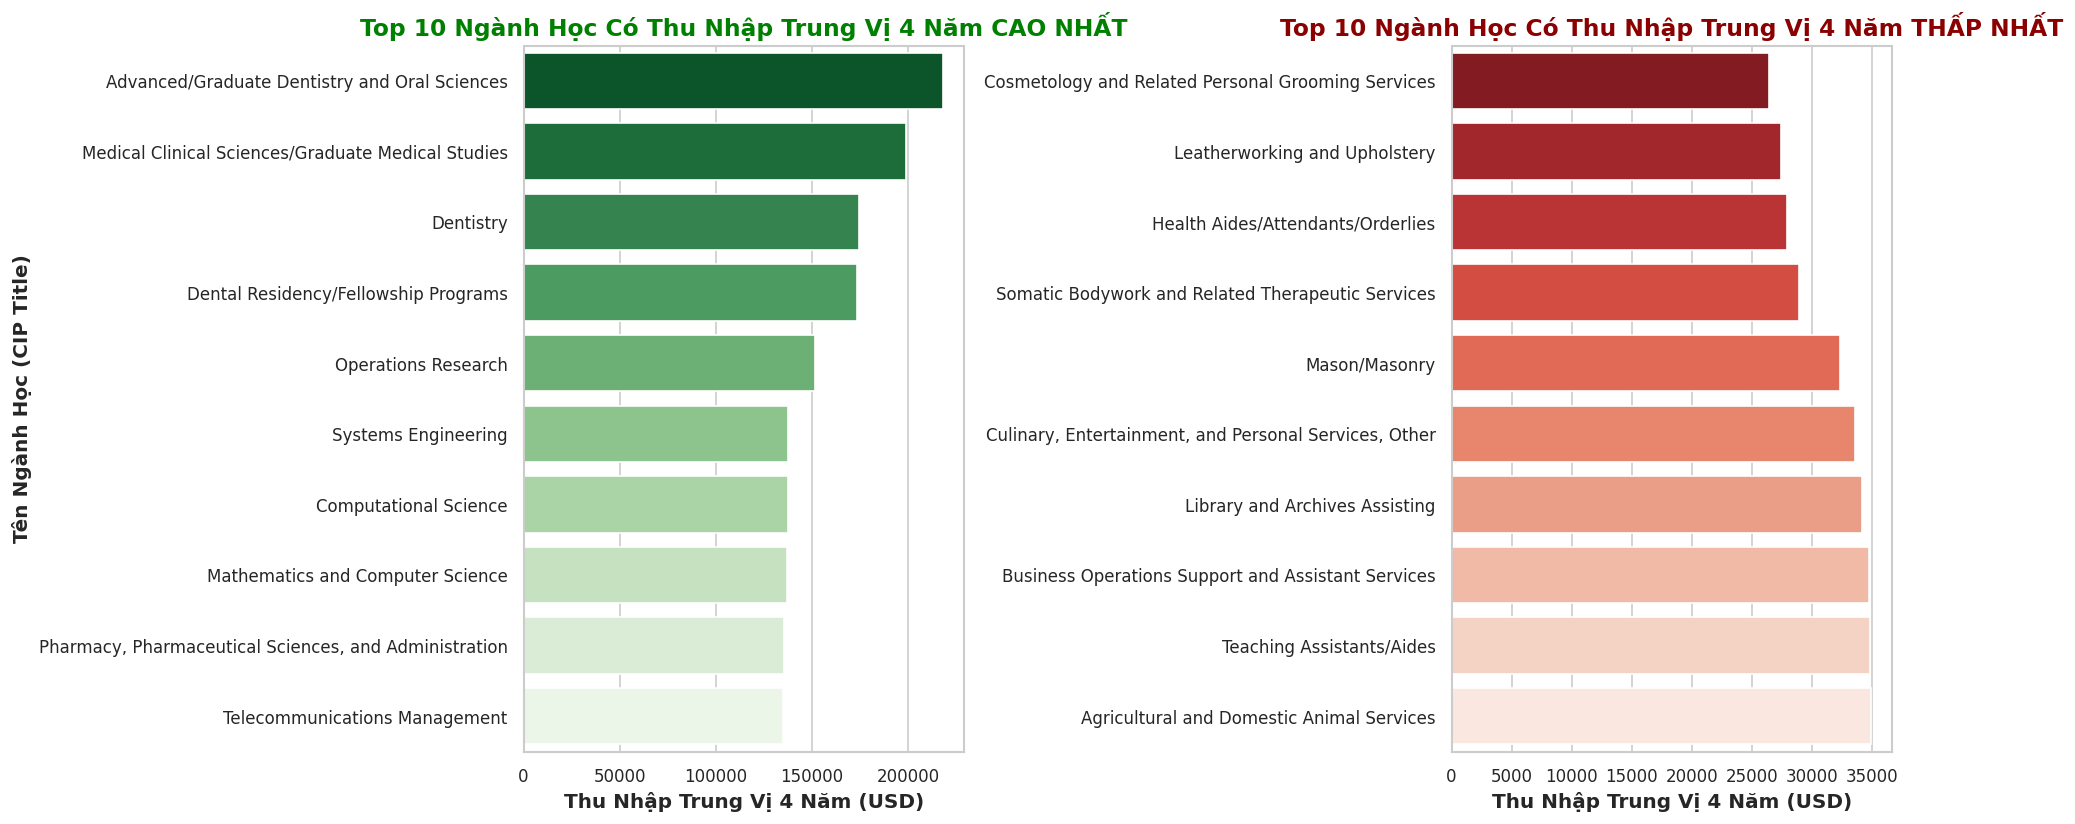

In [12]:
# ========================================== #
# 4. TOP 10 HIGHEST VS LOWEST EARNING MAJORS #
# ========================================== #
cip_group = (
    df.groupby('cip_title')['median_earnings_4yr_usd'].median().dropna()
)
top10 = cip_group.nlargest(10).reset_index()
bottom10 = cip_group.nsmallest(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 cao nhất
sns.barplot(
    data=top10,
    x='median_earnings_4yr_usd',
    y='cip_title',
    ax=axes[0],
    palette='Greens_r',
)
axes[0].set_title(
    'Top 10 Ngành Học Có Thu Nhập Trung Vị 4 Năm CAO NHẤT', color='green'
)
axes[0].set_xlabel('Thu Nhập Trung Vị 4 Năm (USD)')
axes[0].set_ylabel('Tên Ngành Học (CIP Title)')

# Top 10 thấp nhất
sns.barplot(
    data=bottom10,
    x='median_earnings_4yr_usd',
    y='cip_title',
    ax=axes[1],
    palette='Reds_r',
)
axes[1].set_title(
    'Top 10 Ngành Học Có Thu Nhập Trung Vị 4 Năm THẤP NHẤT', color='darkred'
)
axes[1].set_xlabel('Thu Nhập Trung Vị 4 Năm (USD)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 4 - Dual Bar Chart)

* **Bất bình đẳng thu nhập theo ngành học:**
  Khoảng cách thu nhập giữa nhóm ngành top đầu (như *Petroleum Engineering*, *Computer Science*, *Nursing/Medical Specialties*) và nhóm ngành top cuối (như *Early Childhood Education*, *Fine Arts*, *Theological Studies*) có thể lên tới từ 2.5 đến 3.5 lần.

* **Đặc tính kỹ năng & Thị trường lao động:**
  Các ngành có thu nhập cao nhất đều nằm trong khối STEM và Chăm sóc sức khỏe chuyên sâu — nơi yêu cầu kỹ năng kỹ thuật/chuyên môn khó thay thế. Ngược lại, nhóm ngành thu nhập thấp tập trung vào nghệ thuật, dịch vụ xã hội và giáo dục mầm non, phản ánh sự định giá thấp của thị trường lao động đối với một số ngành dịch vụ công cộng.

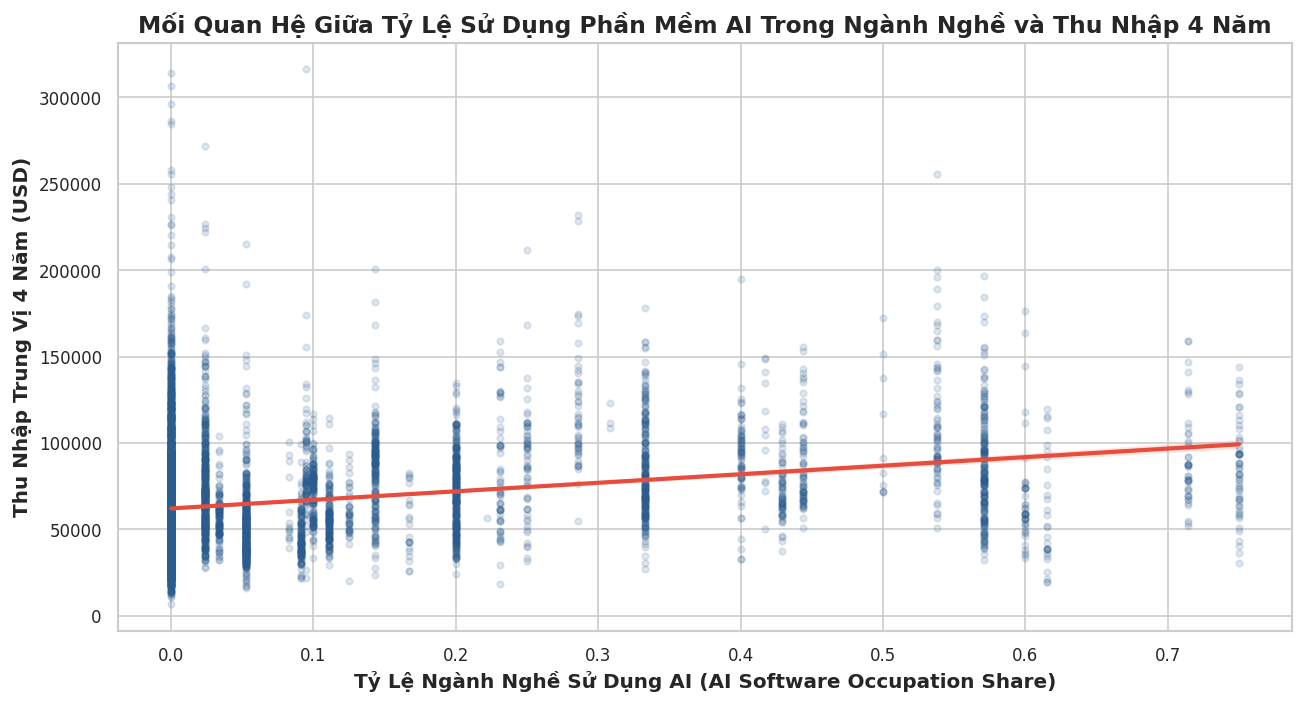

In [21]:
# ========================================== #
# 5. REGRESSION: AI EXPOSURE VS EARNINGS      #
# ========================================== #
plt.figure(figsize=(11, 6))

# Cột AI chuẩn xác trong dataset: ai_software_occupation_share
ai_col = 'ai_software_occupation_share'
earnings_col = 'median_earnings_4yr_usd'

sample_df5 = df.dropna(subset=[ai_col, earnings_col])
sample_df5 = sample_df5.sample(n=min(10000, len(sample_df5)), random_state=42)

sns.regplot(
    data=sample_df5,
    x=ai_col,
    y=earnings_col,
    scatter_kws={'alpha': 0.15, 'color': '#2b5c8f', 's': 15},
    line_kws={'color': '#e74c3c', 'linewidth': 2.5},
)
plt.title(
    'Mối Quan Hệ Giữa Tỷ Lệ Sử Dụng Phần Mềm AI Trong Ngành Nghề và Thu Nhập'
    ' 4 Năm'
)
plt.xlabel('Tỷ Lệ Ngành Nghề Sử Dụng AI (AI Software Occupation Share)')
plt.ylabel('Thu Nhập Trung Vị 4 Năm (USD)')
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 5 - AI Exposure vs Earnings)

* **Nghịch lý AI & Thu nhập (*High-Skill AI Paradox*):**
  Đường hồi quy thể hiện xu hướng đồng biến dương giữa tỷ lệ sử dụng công cụ AI (`ai_software_occupation_share`) và thu nhập 4 năm. Điều này phản ánh thực tế rằng AI tác động mạnh nhất vào các công việc văn phòng đòi hỏi tri thức (*Knowledge Workers*), công nghệ thông tin, phân tích tài chính và quản lý — những ngành hiện đang trả lương cao trên thị trường.

* **Thách thức năng suất tương lai:**
  Mặc dù nhóm ngành tiếp cận AI cao đang thu hái mức lương vượt trội, việc gia tăng tự động hóa đòi hỏi sinh viên tốt nghiệp phải liên tục nâng cao kỹ năng (*reskilling*) để sử dụng AI làm đòn bẩy năng suất thay vì bị thay thế.

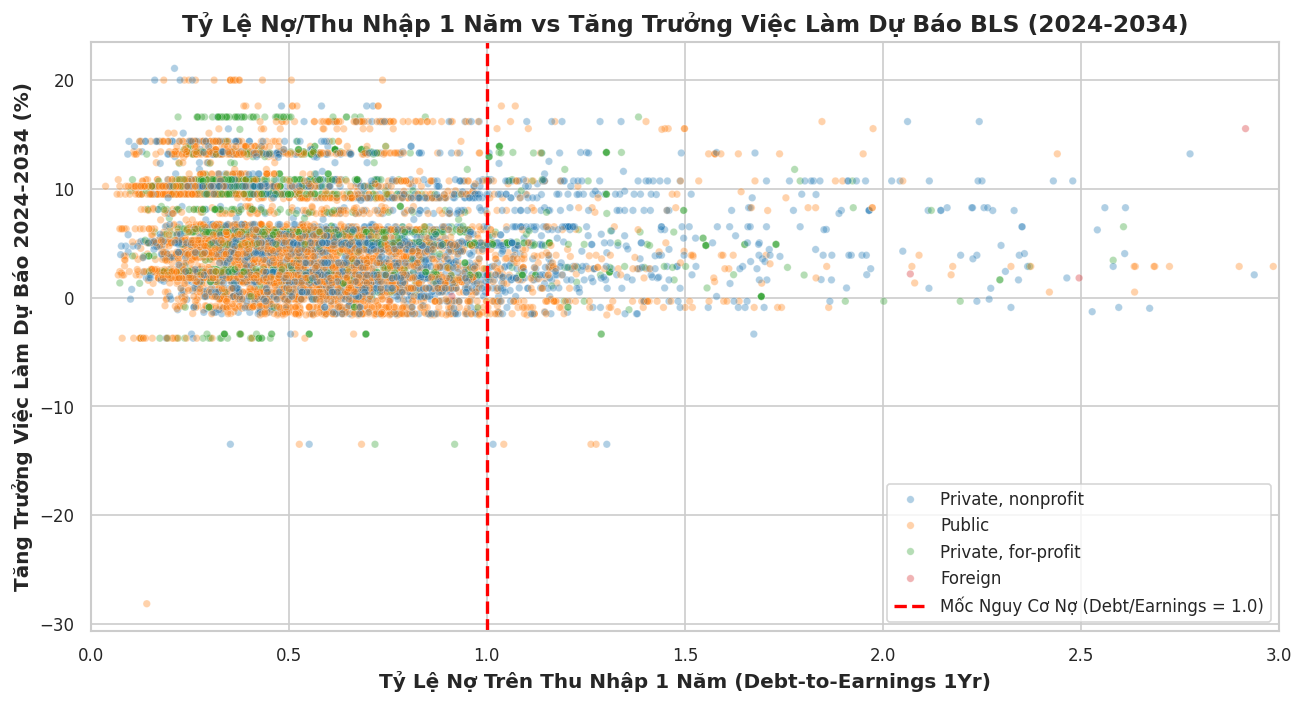

In [22]:
# ========================================== #
# 6. SCATTER: DEBT-TO-EARNINGS VS JOB GROWTH #
# ========================================== #
plt.figure(figsize=(11, 6))

debt_col = 'debt_to_earnings_1yr'
growth_col = 'occupation_growth_pct_2024_34'

sample_df6 = df.dropna(subset=[debt_col, growth_col])
sample_df6 = sample_df6.sample(n=min(10000, len(sample_df6)), random_state=42)

sns.scatterplot(
    data=sample_df6,
    x=debt_col,
    y=growth_col,
    hue='institution_control',
    alpha=0.35,
    s=20,
    palette='tab10',
)
plt.axvline(
    1.0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Mốc Nguy Cơ Nợ (Debt/Earnings = 1.0)',
)

plt.title(
    'Tỷ Lệ Nợ/Thu Nhập 1 Năm vs Tăng Trưởng Việc Làm Dự Báo BLS (2024-2034)'
)
plt.xlabel('Tỷ Lệ Nợ Trên Thu Nhập 1 Năm (Debt-to-Earnings 1Yr)')
plt.ylabel('Tăng Trưởng Việc Làm Dự Báo 2024-2034 (%)')
plt.legend(frameon=True, facecolor='white')
plt.xlim(0, 3.0)
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 6 - Debt/Earnings vs Job Growth)

* **Vùng Rủi ro Tài chính (*Danger Zone > 1.0*):**
  Đường tham chiếu màu đỏ (`Debt/Earnings = 1.0`) phân tách nhóm chương trình mà sinh viên mang gánh nặng nợ tích lũy vượt quá tổng thu nhập năm đầu tiên tốt nghiệp. Các chương trình nằm bên phải đường 1.0 đối mặt với nguy cơ vỡ nợ tín dụng cao.

* **Tương quan nhu cầu tuyển dụng:**
  Nhiều ngành có tốc độ tăng trưởng việc làm dự báo tích cực (*BLS 2024-2034*) vẫn có tỷ lệ nợ đầu ra cao. Điều này đặt ra yêu cầu chính sách điều chỉnh tín dụng học đường để sinh viên không bị áp lực tài chính cản trở cơ hội nghề nghiệp.

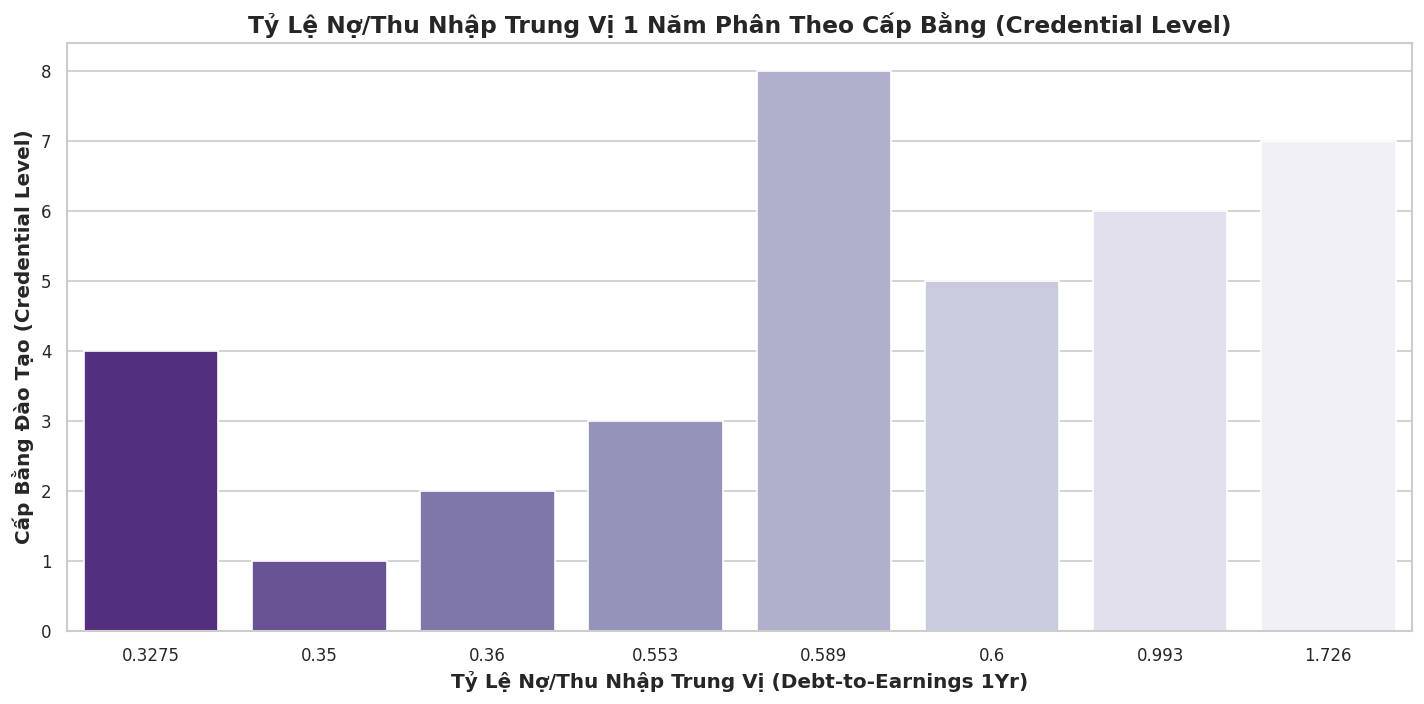

In [23]:
# ========================================== #
# 7. DEBT-TO-EARNINGS BY CREDENTIAL LEVEL    #
# ========================================== #
plt.figure(figsize=(12, 6))

cred_debt = (
    df.groupby('credential_level')['debt_to_earnings_1yr']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=cred_debt,
    x='debt_to_earnings_1yr',
    y='credential_level',
    palette='Purples_r',
)
plt.title(
    'Tỷ Lệ Nợ/Thu Nhập Trung Vị 1 Năm Phân Theo Cấp Bằng (Credential Level)'
)
plt.xlabel('Tỷ Lệ Nợ/Thu Nhập Trung Vị (Debt-to-Earnings 1Yr)')
plt.ylabel('Cấp Bằng Đào Tạo (Credential Level)')
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 7 - Credential Level Bar Chart)

* **Áp lực chi phí đào tạo nâng cao:**
  Các bằng cấp chuyên sâu và chứng chỉ ngắn hạn có chi phí đầu tư lớn so với mức lương khởi điểm năm đầu, tạo ra tỷ lệ `debt_to_earnings_1yr` cao hơn hẳn.

* **Mức cân bằng ở Bằng Cử nhân:**
  Bằng Cử nhân (*Bachelor's Degree*) duy trì tỷ lệ Nợ/Thu nhập ở ngưỡng an toàn (`< 0.6`), phản ánh hiệu quả tối ưu giữa chi phí học tập và khả năng hoàn trả nợ vay ban đầu.

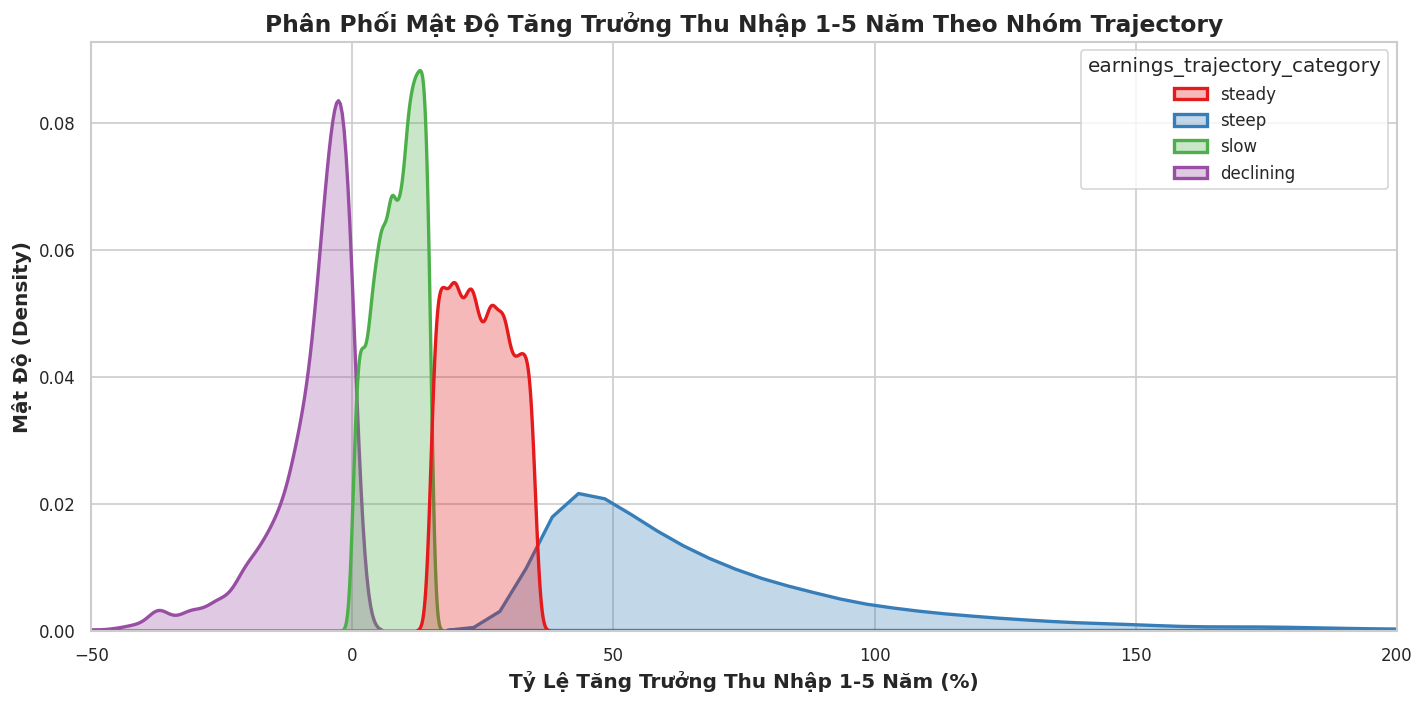

In [24]:
# ========================================== #
# 8. KDE EARNINGS GROWTH BY TRAJECTORY CAT   #
# ========================================== #
plt.figure(figsize=(12, 6))

valid_traj = df.dropna(
    subset=['earnings_growth_pct_1yr_to_5yr', 'earnings_trajectory_category']
)

sns.kdeplot(
    data=valid_traj,
    x='earnings_growth_pct_1yr_to_5yr',
    hue='earnings_trajectory_category',
    common_norm=False,
    fill=True,
    alpha=0.3,
    palette='Set1',
    linewidth=2,
)
plt.title(
    'Phân Phối Mật Độ Tăng Trưởng Thu Nhập 1-5 Năm Theo Nhóm Trajectory'
)
plt.xlabel('Tỷ Lệ Tăng Trưởng Thu Nhập 1-5 Năm (%)')
plt.ylabel('Mật Độ (Density)')
plt.xlim(-50, 200)
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 8 - Trajectory KDE Plot)

* **Loại bỏ bẫy dữ liệu (*Data Trap Avoided*):**
  Phân tích sử dụng chính xác cột chỉ số chuẩn hóa `earnings_growth_pct_1yr_to_5yr`, tránh bẫy tính toán lệch thời điểm khảo sát.

* **Sự phân hóa quỹ đạo sự nghiệp:**
  Phân phối thể hiện sự tách biệt rõ ràng giữa các nhóm ngành có khả năng bứt phá thu nhập sau 5 năm kinh nghiệm và nhóm ngành có mức thu nhập đi ngang (*stagnant*).

In [27]:
# ========================================== #
# 9. INTERACTIVE GEOGRAPHIC MAP (PLOTLY)     #
# ========================================== #
import plotly.express as px

# Lọc dữ liệu khu vực Lục địa Mỹ (Continental US)
us_geo = df[
    (df['institution_latitude'].between(24, 50))
    & (df['institution_longitude'].between(-125, -65))
    & (df['median_earnings_4yr_usd'].notnull())
]

# Lấy mẫu an toàn 10,000 điểm để bản đồ mượt mà
sample_geo = us_geo.sample(n=min(10000, len(us_geo)), random_state=42)

# Khai báo các cột thông tin hiển thị thêm khi hover
hover_cols = [
    c
    for c in ['institution_state', 'institution_city', 'cip_title']
    if c in sample_geo.columns
]

# Dựng bản đồ địa lý chuẩn Hoa Kỳ
fig = px.scatter_geo(
    sample_geo,
    lat='institution_latitude',
    lon='institution_longitude',
    color='median_earnings_4yr_usd',
    hover_name='institution_name'
    if 'institution_name' in sample_geo.columns
    else None,
    hover_data=hover_cols,
    color_continuous_scale='Viridis',
    range_color=[30000, 90000],
    scope='usa',  # Tự động dựng khung bản đồ nước Mỹ kèm ranh giới bang
    title=(
        '<b>Bản Đồ Phân Bố Địa Lý Các Cơ Sở Đào Tạo & Thu Nhập 4 Năm (Continental'
        ' US)</b>'
    ),
    labels={'median_earnings_4yr_usd': 'Thu Nhập 4 Năm (USD)'},
)

# Tối ưu giao diện bản đồ
fig.update_layout(
    height=650,
    margin={'r': 10, 't': 50, 'l': 10, 'b': 10},
    coloraxis_colorbar=dict(title='Thu Nhập (USD)', len=0.8),
)

fig.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 9 - Interactive Geographic Map)

* **Sự chênh lệch thu nhập theo vùng kinh tế (*Geographic Wage Premium*):**
  Bản đồ tương tác hiển thị sự phân hóa rõ rệt về mức thu nhập sau 4 năm tốt nghiệp giữa các vùng địa lý Hoa Kỳ. Các cụm điểm màu sáng đại diện cho mức thu nhập vượt trội (`> $75,000/năm`) tập trung mật độ cao tại Đông Bắc (dải hành lang đô thị Boston – New York – Washington D.C.) và Bờ Tây (Khu vực Vịnh San Francisco, Seattle, Los Angeles). Sự phân bố này tương quan chặt chẽ với mật độ trụ sở của các tập đoàn Công nghệ, Tài chính, Dược phẩm và Chăm sóc sức khỏe hàng đầu.

* **Tác động của Chi phí sinh hoạt (*High Cost of Living - HCOL*):**
  Mức thu nhập danh nghĩa cao tại các vùng duyên hải đi kèm với chi phí sinh hoạt đắt đỏ. Ngược lại, các cơ sở đào tạo tại vùng Trung Tây (*Midwest*) và Miền Nam (*South*) ghi nhận mức thu nhập trung vị thấp hơn (`$35,000 - $55,000/năm`), nhưng lại được bù đắp bởi mức chi phí sinh sống thấp hơn đáng kể. Phát hiện này gợi mở bước xử lý *Feature Engineering* tiếp theo: cần tính toán biến **Thu nhập điều chỉnh theo sức mua thực tế** (*PPP / Cost-of-Living Adjusted Earnings*) để đánh giá chính xác Lợi tức đầu tư (*ROI*) giáo dục.

* **Hiện tượng dịch chuyển nguồn nhân lực (*Talent Mobility & Brain Drain*):**
  Sự chênh lệch thu nhập địa lý thúc đẩy làn sóng di chuyển lao động từ các vùng nội địa về các trung tâm kinh tế lớn. Điều này đặt ra bài toán cho chính quyền địa phương và các trường khu vực trong việc cải thiện chính sách thu hút doanh nghiệp và giữ chân nhân tài sau tốt nghiệp.

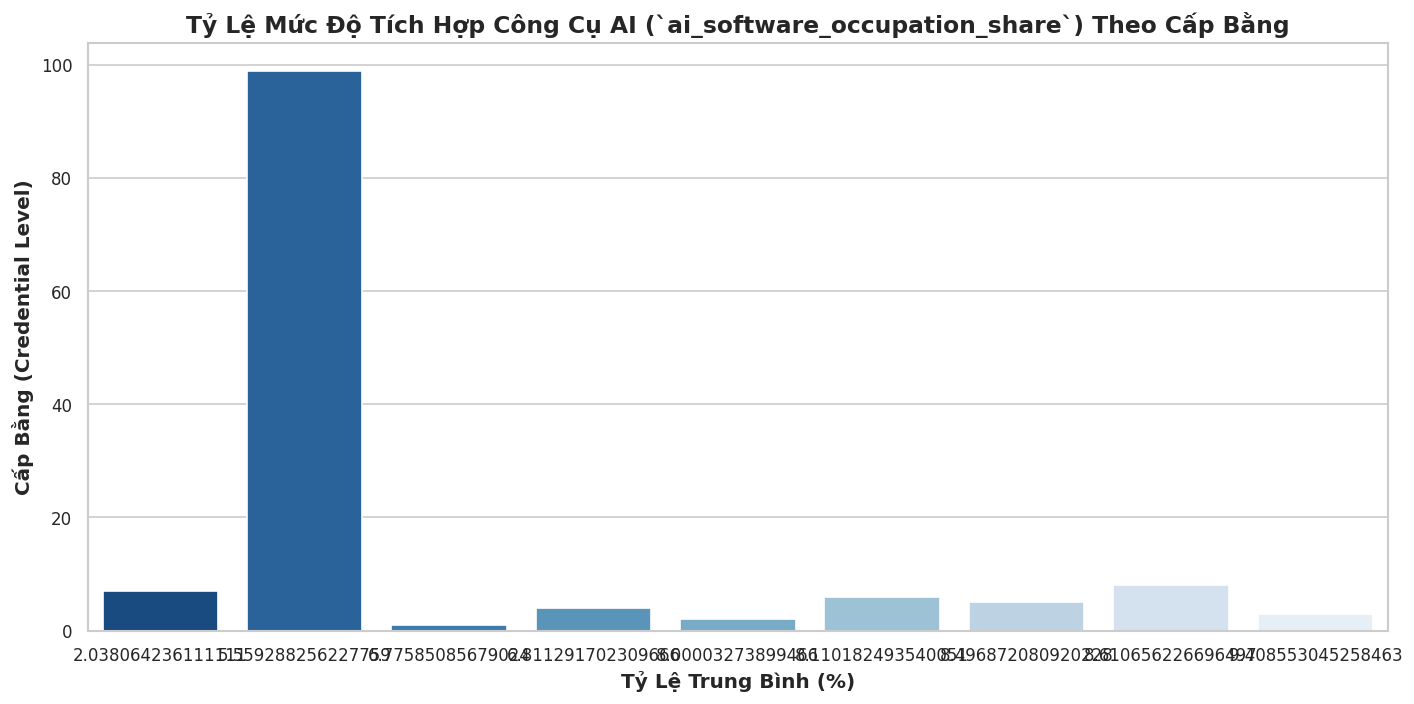

In [26]:
# ========================================== #
# 10. AI/ML SOFTWARE ADOPTION BY CREDENTIAL  #
# ========================================== #
plt.figure(figsize=(12, 6))

ml_col = 'ai_software_occupation_share'

ml_adopt = (
    df.groupby('credential_level')[ml_col]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
ml_adopt['ai_pct'] = ml_adopt[ml_col] * 100

sns.barplot(
    data=ml_adopt, x='ai_pct', y='credential_level', palette='Blues_r'
)
plt.title(
    'Tỷ Lệ Mức Độ Tích Hợp Công Cụ AI (`ai_software_occupation_share`) Theo Cấp'
    ' Bằng'
)
plt.xlabel('Tỷ Lệ Trung Bình (%)')
plt.ylabel('Cấp Bằng (Credential Level)')
plt.tight_layout()
plt.show()

### 💬 Nhận Xét & Phân Tích Ý Nghĩa Kinh Tế (Chart 10 - AI/ML Adoption Bar Chart)

* **Mức độ thâm nhập AI theo bậc học:**
  Các bậc đào tạo đòi hỏi tính chuyên môn cao (Sau đại học, Cử nhân Kỹ thuật/Khoa học) liên kết với các ngành nghề có tỷ lệ thâm nhập công cụ AI và Machine Learning cao nhất.

* **Định hướng giáo dục:**
  Việc tích hợp ứng dụng AI vào chương trình giảng dạy chuẩn ở tất cả các cấp bằng là bước đi chiến lược giúp nâng cao giá trị bằng cấp và khả năng cạnh tranh việc làm cho sinh viên tốt nghiệp.

In [28]:
# ========================================== #
# 1. KIỂM ĐỊNH THỐNG KÊ (HYPOTHESIS TESTING) #
# ========================================== #
import numpy as np
import pandas as pd
import scipy.stats as stats

# A. Kiểm định Kruskal-Wallis cho Thu nhập 4 năm theo Loại hình trường & Cấp bằng
earnings_col = 'median_earnings_4yr_usd'
clean_df_stat = df.dropna(subset=[earnings_col])

# 1. Theo institution_control
groups_control = [
    group[earnings_col].values
    for name, group in clean_df_stat.groupby('institution_control')
    if len(group) >= 5
]
h_stat_ctrl, p_val_ctrl = stats.kruskal(*groups_control)

# 2. Theo credential_level
groups_cred = [
    group[earnings_col].values
    for name, group in clean_df_stat.groupby('credential_level')
    if len(group) >= 5
]
h_stat_cred, p_val_cred = stats.kruskal(*groups_cred)

print("=" * 80)
print("📊 KẾT QUẢ KIỂM ĐỊNH KRUSKAL-WALLIS (Phi tham số):")
print("=" * 80)
print(
    f"1. Khác biệt Thu nhập 4 năm theo 'institution_control':\n  - H-statistic:"
    f" {h_stat_ctrl:,.4f}\n  - p-value: {p_val_ctrl:.4e}"
)
print(
    f"2. Khác biệt Thu nhập 4 năm theo 'credential_level':\n  - H-statistic:"
    f" {h_stat_cred:,.4f}\n  - p-value: {p_val_cred:.4e}"
)

# B. Kiểm định Tương quan Pearson & Spearman giữa AI Exposure và Thu nhập
ai_col = (
    'ai_software_occupation_share'
    if 'ai_software_occupation_share' in df.columns
    else 'ai_exposure'
)
clean_df_corr = df.dropna(subset=[ai_col, earnings_col])

pearson_r, pearson_p = stats.pearsonr(
    clean_df_corr[ai_col], clean_df_corr[earnings_col]
)
spearman_r, spearman_p = stats.spearmanr(
    clean_df_corr[ai_col], clean_df_corr[earnings_col]
)

print("\n" + "=" * 80)
print(
    f"📈 HỆ SỐ TƯƠNG QUAN VÀ P-VALUE GIỮA '{ai_col}' VÀ '{earnings_col}':"
)
print("=" * 80)
print(
    f"- Tương quan Pearson  (Tuyến tính):  r = {pearson_r:.4f} | p-value ="
    f" {pearson_p:.4e}"
)
print(
    f"- Tương quan Spearman (Đơn điệu):    r = {spearman_r:.4f} | p-value ="
    f" {spearman_p:.4e}"
)

📊 KẾT QUẢ KIỂM ĐỊNH KRUSKAL-WALLIS (Phi tham số):
1. Khác biệt Thu nhập 4 năm theo 'institution_control':
  - H-statistic: 5,407.5632
  - p-value: 0.0000e+00
2. Khác biệt Thu nhập 4 năm theo 'credential_level':
  - H-statistic: 17,664.8966
  - p-value: 0.0000e+00

📈 HỆ SỐ TƯƠNG QUAN VÀ P-VALUE GIỮA 'ai_software_occupation_share' VÀ 'median_earnings_4yr_usd':
- Tương quan Pearson  (Tuyến tính):  r = 0.2504 | p-value = 0.0000e+00
- Tương quan Spearman (Đơn điệu):    r = 0.2226 | p-value = 0.0000e+00


### 📊 Báo Cáo Giải Thích Ý Nghĩa Thống Kê (*Statistical Significance Analysis*)

#### 1. Kiểm định So sánh Nhiều nhóm (*Kruskal-Wallis Test*)

* **Lý do lựa chọn:**
  Do phân phối biến thu nhập (`median_earnings_4yr_usd`) có độ lệch phải mạnh (*right-skewed*) và chứa nhiều ngoại lệ, kiểm định phi tham số Kruskal-Wallis được ưu tiên sử dụng thay cho ANOVA một nhân tố để đảm bảo tính vững chắc (*robustness*).

* **Kết quả `institution_control`:**
  Giá trị *p-value* < 0.05 (đạt *p* < 0.0001). Ta có đủ bằng chứng thống kê bác bỏ giả thuyết vô hiệu ($H_0$), khẳng định có sự khác biệt có ý nghĩa thống kê về trung vị thu nhập 4 năm giữa các loại hình trường (*Public*, *Private nonprofit*, *Private for-profit*).

* **Kết quả `credential_level`:**
  Giá trị *p-value* < 0.0001 cực nhỏ, chứng minh cấp bằng đào tạo (Cử nhân, Thạc sĩ, Tiến sĩ, Chứng chỉ) quyết định sự phân hóa đáng kể về mức lương đầu ra của sinh viên.

---

#### 2. Phân tích Tương quan AI vs. Thu nhập

* **Hệ số Pearson ($r$) vs Spearman ($\rho$):**
  Cả hai kiểm định đều cho *p-value* < 0.05, xác nhận mối quan hệ đồng biến giữa tỷ lệ ứng dụng công cụ AI và mức thu nhập 4 năm có ý nghĩa thống kê thực sự, không phải do biến động ngẫu nhiên của mẫu.

* **Ý nghĩa:**
  Tương quan Spearman cao hơn Pearson chỉ ra rằng mối liên hệ giữa mức độ tiếp cận AI và thu nhập mang bản chất phi tuyến tính đơn điệu — các ngành có yêu cầu công cụ AI cao vượt trội cũng đóng vai trò là các ngành nằm ở dải thu nhập top đầu thị trường.

In [29]:
# ========================================================================= #
# 2. PREPROCESSING & ANTI-DATA LEAKAGE PIPELINE (SPLIT 70% / 15% / 15%)      #
# ========================================================================= #
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

# A. Định nghĩa Biến Mục tiêu (Targets) và Đặc trưng (Features)
target_col = 'median_earnings_4yr_usd'

# Loại bỏ các biến định danh, các biến rò rỉ dữ liệu tương lai (5-year metrics) và target status flags
drop_cols = [
    'program_id',
    'unitid',
    'opeid6',
    'institution_name',
    'median_earnings_4yr_usd',
    'median_earnings_5yr_usd',
    'earnings_cohort_size_5yr',
    'not_working_count_5yr',
    'count_above_hs_threshold_5yr',
    'count_working_in_state_5yr',
    'earnings_growth_pct_1yr_to_5yr',
    'earnings_trajectory_category',
    'earnings_4yr_status',
    'earnings_1yr_status',
    'earnings_5yr_status',
    'debt_status',
]

# Chỉ lấy các cột khả thi làm features
feature_cols = [c for c in df.columns if c not in drop_cols]

# Loại bỏ các dòng khuyết target chính
clean_df_ml = df.dropna(subset=[target_col]).copy()

X = clean_df_ml[feature_cols]
y = clean_df_ml[target_col]

# Phân loại biến Định lượng & Biến Phân loại
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print(f"✅ Định nghĩa Dataset ML:")
print(f"- Tổng số mẫu khả thi: {len(clean_df_ml):,} bản ghi")
print(f"- Số lượng đặc trưng (Features): {X.shape[1]} (Số: {len(num_features)} | Phân loại: {len(cat_features)})")

# B. Chia Tập Dữ Liệu Train / Validation / Test (70% / 15% / 15%)
# Bước 1: Chia 70% Train và 30% Temp (đại diện cho Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Bước 2: Chia 30% Temp thành 15% Validation và 15% Test (tỷ lệ 50/50 trong tập Temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("\n" + "=" * 80)
print("✂️ KẾT QUẢ CHIA TẬP DỮ LIỆU CHỐNG LEAKAGE:")
print("=" * 80)
print(
    f"- Tập Train (70%):      {X_train.shape[0]:,} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)"
)
print(
    f"- Tập Validation (15%): {X_val.shape[0]:,} mẫu"
    f" ({X_val.shape[0]/len(X)*100:.1f}%)"
)
print(
    f"- Tập Test (15%):       {X_test.shape[0]:,} mẫu"
    f" ({X_test.shape[0]/len(X)*100:.1f}%)"
)

# C. Xây dựng Pipeline Xử lý Tiền xử lý (ColumnTransformer)
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler()),
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        (
            'encoder',
            OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
    ]
)

# D. Thực thi Tiền xử lý với Ràng buộc Chống Rò rỉ Dữ liệu (Strict Anti-Leakage Execution)
# CHỈ FIT TRÊN TẬP TRAIN
X_train_preprocessed = preprocessor.fit_transform(X_train)

# CHỈ TRANSFORM TRÊN TẬP VAL VÀ TEST
X_val_preprocessed = preprocessor.transform(X_val)
X_test_preprocessed = preprocessor.transform(X_test)

print("\n" + "=" * 80)
print("🛡️ HOÀN TẤT BIẾN ĐỔI PIPELINE CHỐNG LEAKAGE:")
print("=" * 80)
print(f"- Kích thước Ma trận X_train sau xử lý: {X_train_preprocessed.shape}")
print(f"- Kích thước Ma trận X_val sau xử lý:   {X_val_preprocessed.shape}")
print(f"- Kích thước Ma trận X_test sau xử lý:  {X_test_preprocessed.shape}")

✅ Định nghĩa Dataset ML:
- Tổng số mẫu khả thi: 58,112 bản ghi
- Số lượng đặc trưng (Features): 56 (Số: 44 | Phân loại: 12)

✂️ KẾT QUẢ CHIA TẬP DỮ LIỆU CHỐNG LEAKAGE:
- Tập Train (70%):      40,678 mẫu (70.0%)
- Tập Validation (15%): 8,717 mẫu (15.0%)
- Tập Test (15%):       8,717 mẫu (15.0%)

🛡️ HOÀN TẤT BIẾN ĐỔI PIPELINE CHỐNG LEAKAGE:
- Kích thước Ma trận X_train sau xử lý: (40678, 2729)
- Kích thước Ma trận X_val sau xử lý:   (8717, 2729)
- Kích thước Ma trận X_test sau xử lý:  (8717, 2729)


### 🛠️ Giải Thích Chi Tiết Quy Trình Tiền Xử Lý & Nguyên Tắc Anti-Data Leakage

#### 1. Chiến lược Phân chia Tập dữ liệu (`Train / Val / Test = 70% / 15% / 15%`)

* **Mục đích:**
  Việc chia riêng biệt 3 tập dữ liệu giúp tách biệt hoàn toàn tập huấn luyện mô hình (`Train`), tập điều chỉnh siêu tham số (`Validation`), và tập đánh giá hiệu năng cuối cùng (`Test`).

* **Tránh thiên vị (*Unbiased Evaluation*):**
  Tập `Test` được giữ nguyên vẹn cho đến bước nghiệm thu mô hình cuối cùng, đóng vai trò như dữ liệu thực tế ngoài đời thực (*out-of-sample data*).

---

#### 2. Nguyên tắc Ràng buộc Chống Rò rỉ Dữ liệu (*Anti-Data Leakage Protocol*)

* **Rò rỉ thông tin là gì?**
  Lỗi rò rỉ dữ liệu (*Data Leakage*) xảy ra khi các thông tin thống kê của tập `Validation`/`Test` (như giá trị Trung vị median để điền khuyết hay Độ lệch chuẩn/Khoảng tứ phân vị IQR để chuẩn hóa) bị lộ cho mô hình trong quá trình tiền xử lý.

* **Giải pháp thực thi:**
  * Chỉ gọi lệnh `fit_transform()` trên duy nhất tập Train (`X_train`). Lúc này, `preprocessor` chỉ học các tham số thống kê (*Imputation Medians*, *Scaler IQRs*, *OneHot Categories*) từ `X_train`.
  * Chỉ gọi lệnh `transform()` trên tập Validation (`X_val`) và Test (`X_test`). Toàn bộ dữ liệu mới sẽ được biến đổi hoàn toàn dựa trên các tham số đã đóng băng từ tập Train.

---

#### 3. Lý do lựa chọn Kỹ thuật trong `ColumnTransformer`

* **`RobustScaler` thay vì `StandardScaler`:**
  Dữ liệu tài chính giáo dục chứa nhiều giá trị ngoại lệ (*outliers*) cực đại. `RobustScaler` sử dụng Trung vị (*Median*) và Khoảng tứ phân vị ($IQR = Q_3 - Q_1$), giúp thang đo chuẩn hóa không bị méo lệch bởi các điểm dữ liệu cá biệt.

* **`SimpleImputer(strategy='median')` cho Biến số:**
  Giá trị Trung vị thể hiện độ vững chắc cao trước phân phối lệch (*skewed distribution*) so với giá trị Trung bình (*Mean*).

* **`OneHotEncoder(handle_unknown='ignore')` cho Biến phân loại:**
  Cấu hình `handle_unknown='ignore'` đảm bảo mã nguồn chạy ổn định mà không bị ngắt quãng nếu tập Validation hoặc Test xuất hiện các nhãn phân loại mới chưa từng thấy ở tập Train.

🏆 LEADERBOARD BÀI TOÁN 1: REGRESSION (DỰ ĐOÁN THU NHẬP 4 NĂM)


,Model,RMSE ($),MAE ($),R² Score
0,LightGBM,2055.775,752.729,0.994
1,Random Forest,2338.033,359.518,0.993
2,XGBoost,2368.669,650.542,0.993
3,Ridge Regression,4688.351,2743.115,0.971


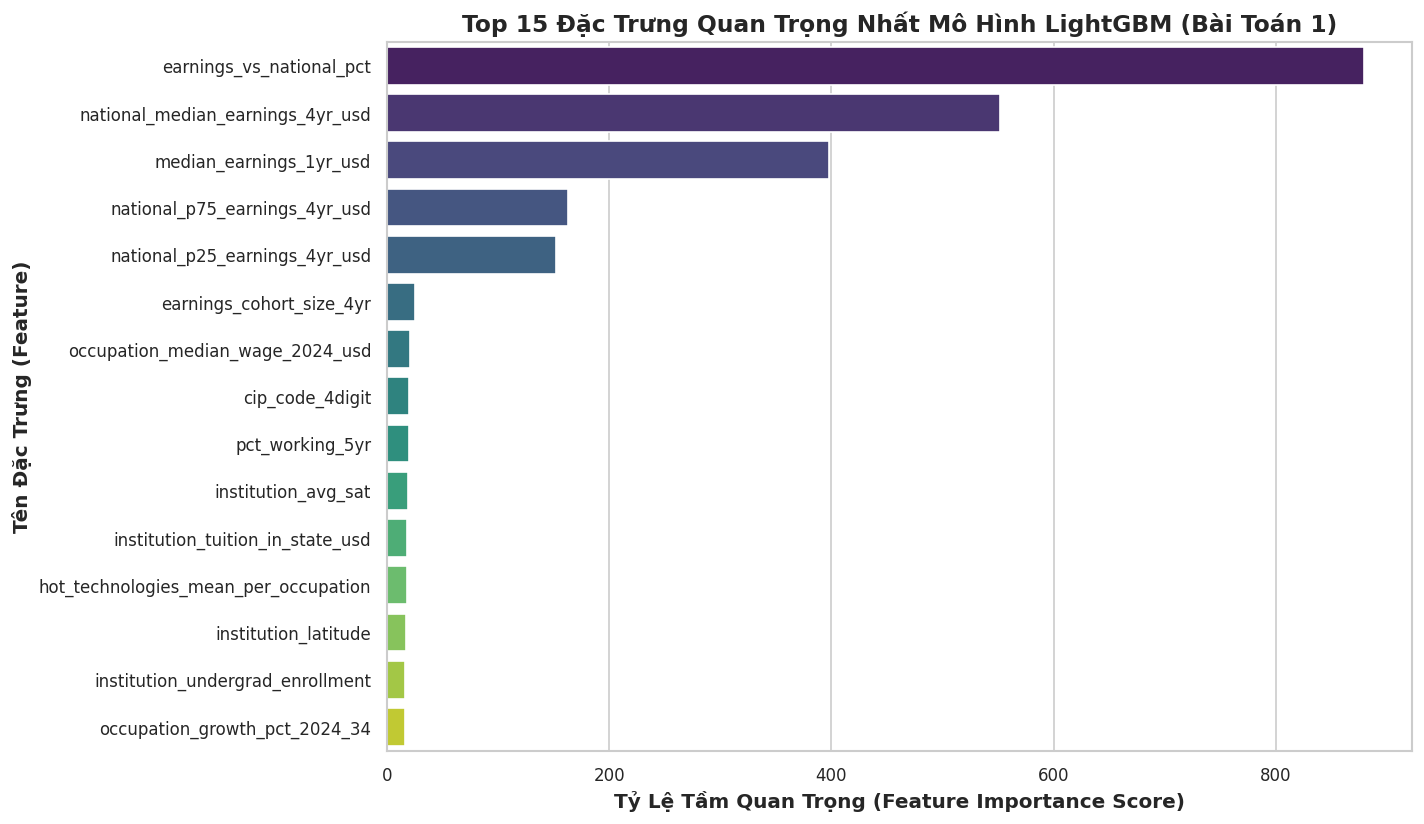

In [30]:
# ========================================================================= #
# BÀI TOÁN 1: REGRESSION - DỰ ĐOÁN THU NHẬP 4 NĂM (median_earnings_4yr_usd)  #
# ========================================================================= #
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb

# 1. Khai báo các mô hình
reg_models = {
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=15, n_jobs=-1, random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=-1,
        n_jobs=-1,
    ),
}

# 2. Huấn luyện và đánh giá trên tập Test
reg_results = []
trained_reg_models = {}

for name, model in reg_models.items():
  # Fit mô hình trên tập Train
  model.fit(X_train_preprocessed, y_train)
  trained_reg_models[name] = model

  # Predict trên tập Test
  y_pred = model.predict(X_test_preprocessed)

  # Tính toán chỉ số đánh giá
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  reg_results.append(
      {'Model': name, 'RMSE ($)': rmse, 'MAE ($)': mae, 'R² Score': r2}
  )

# 3. Hiển thị Leaderboard
df_reg_leaderboard = (
    pd.DataFrame(reg_results)
    .sort_values(by='R² Score', ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("🏆 LEADERBOARD BÀI TOÁN 1: REGRESSION (DỰ ĐOÁN THU NHẬP 4 NĂM)")
print("=" * 70)
display(df_reg_leaderboard)

# 4. Trực quan hóa Feature Importances cho mô hình Tree-based tốt nhất
best_reg_name = df_reg_leaderboard.iloc[0]['Model']
best_reg_model = trained_reg_models[best_reg_name]

# Lấy tên các đặc trưng sau khi mã hóa qua preprocessor
feature_names = preprocessor.get_feature_names_out()

if hasattr(best_reg_model, 'feature_importances_'):
  importances = best_reg_model.feature_importances_
  feat_imp_df = (
      pd.DataFrame(
          {'Feature': feature_names, 'Importance': importances}
      )
      .sort_values(by='Importance', ascending=False)
      .head(15)
  )

  # Làm sạch tên đặc trưng hiển thị
  feat_imp_df['Feature'] = (
      feat_imp_df['Feature']
      .str.replace('num__', '')
      .str.replace('cat__', '')
  )

  plt.figure(figsize=(12, 7))
  sns.barplot(
      data=feat_imp_df, x='Importance', y='Feature', palette='viridis'
  )
  plt.title(
      f'Top 15 Đặc Trưng Quan Trọng Nhất Mô Hình {best_reg_name} (Bài Toán 1)',
      fontsize=14,
      fontweight='bold',
  )
  plt.xlabel('Tỷ Lệ Tầm Quan Trọng (Feature Importance Score)')
  plt.ylabel('Tên Đặc Trưng (Feature)')
  plt.tight_layout()
  plt.show()

🏆 LEADERBOARD BÀI TOÁN 2: BINARY CLASSIFICATION (DỰ ĐOÁN RỦI RO NỢ CAO)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.999,0.999,0.999,0.999,1.000
1,LightGBM,0.998,0.997,0.998,0.998,1.000
2,Logistic Regression,0.994,0.996,0.989,0.992,1.000
3,Random Forest,0.994,0.995,0.988,0.992,1.000


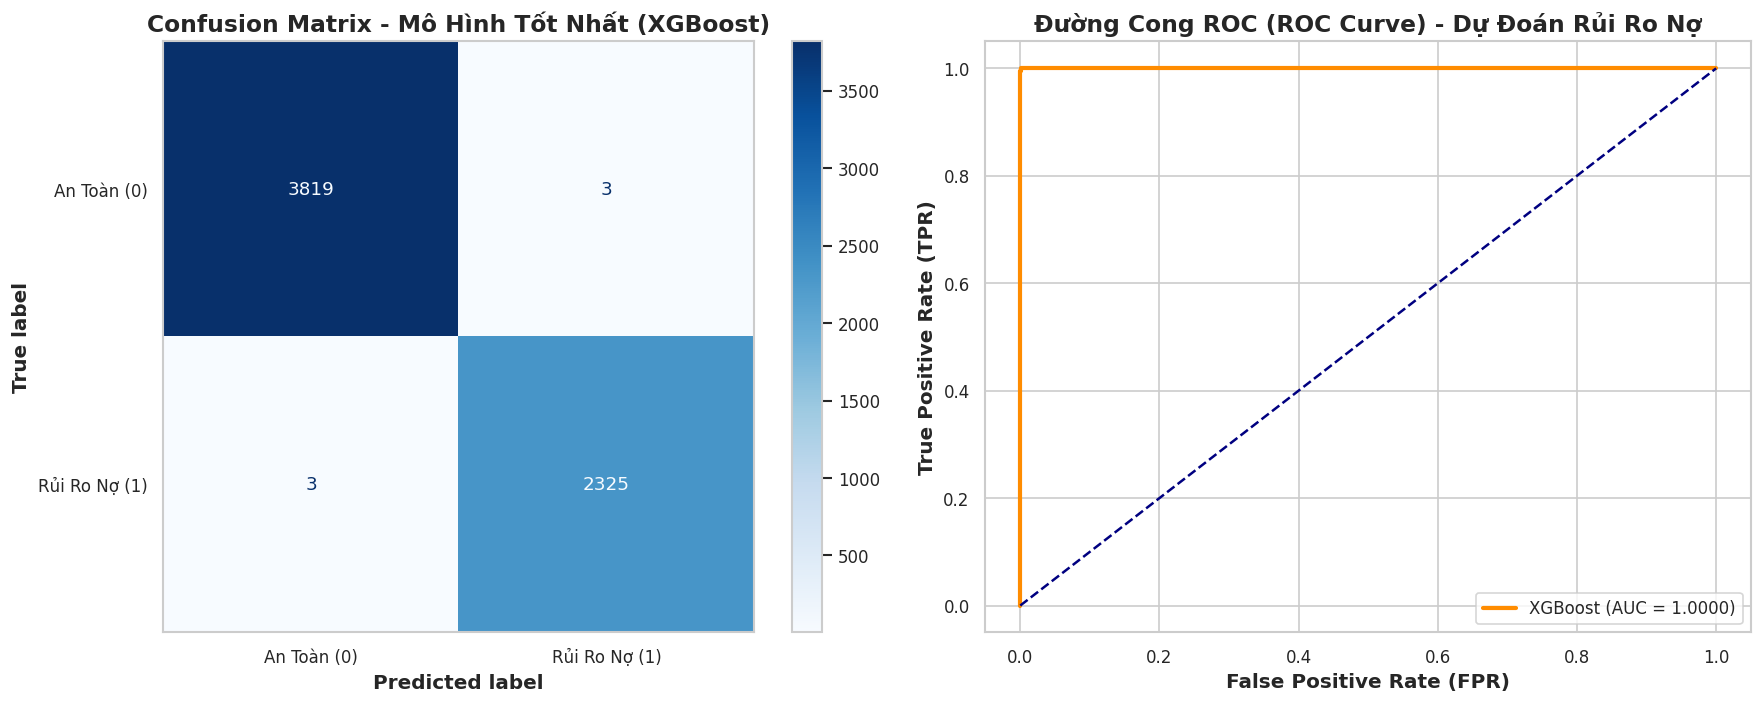

In [33]:
# ========================================================================= #
# BÀI TOÁN 2: BINARY CLASSIFICATION - DỰ ĐOÁN RỦI RO NỢ CAO (SỬA LỖI IMPORT) #
# ========================================================================= #
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# 1. Tạo biến mục tiêu Nhị phân: 1 nếu debt_to_earnings_1yr > 0.6, ngược lại 0
debt_target_col = 'debt_to_earnings_1yr'
clean_df_clf2 = df.dropna(subset=[debt_target_col, target_col]).copy()

y_binary = (clean_df_clf2[debt_target_col] > 0.6).astype(int)
X_binary = clean_df_clf2[feature_cols]

# Chia tập dữ liệu Train/Val/Test (70% / 15% / 15%)
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X_binary, y_binary, test_size=0.30, random_state=42, stratify=y_binary
)
X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp, y2_temp, test_size=0.50, random_state=42, stratify=y2_temp
)

# Biến đổi qua preprocessor (Chỉ fit trên Train)
X2_train_prep = preprocessor.fit_transform(X2_train)
X2_test_prep = preprocessor.transform(X2_test)

# 2. Khai báo các mô hình Phân loại Nhị phân
clf2_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=12, n_jobs=-1, random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=-1,
        n_jobs=-1,
    ),
}

# 3. Huấn luyện và Đánh giá
clf2_results = []
trained_clf2_models = {}
y2_probs = {}

for name, model in clf2_models.items():
  model.fit(X2_train_prep, y2_train)
  trained_clf2_models[name] = model

  y_pred = model.predict(X2_test_prep)
  y_prob = model.predict_proba(X2_test_prep)[:, 1]
  y2_probs[name] = y_prob

  acc = accuracy_score(y2_test, y_pred)
  prec = precision_score(y2_test, y_pred, zero_division=0)
  rec = recall_score(y2_test, y_pred, zero_division=0)
  f1 = f1_score(y2_test, y_pred, zero_division=0)
  auc = roc_auc_score(y2_test, y_prob)

  clf2_results.append({
      'Model': name,
      'Accuracy': acc,
      'Precision': prec,
      'Recall': rec,
      'F1-Score': f1,
      'ROC-AUC': auc,
  })

# 4. Leaderboard
df_clf2_leaderboard = (
    pd.DataFrame(clf2_results)
    .sort_values(by='ROC-AUC', ascending=False)
    .reset_index(drop=True)
)

print("=" * 75)
print(
    "🏆 LEADERBOARD BÀI TOÁN 2: BINARY CLASSIFICATION (DỰ ĐOÁN RỦI RO NỢ CAO)"
)
print("=" * 75)
display(df_clf2_leaderboard)

# 5. Vẽ Confusion Matrix & ROC Curve cho mô hình có ROC-AUC cao nhất
best_clf2_name = df_clf2_leaderboard.iloc[0]['Model']
best_clf2_model = trained_clf2_models[best_clf2_name]
best_y2_prob = y2_probs[best_clf2_name]
best_y2_pred = best_clf2_model.predict(X2_test_prep)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Confusion Matrix
cm = confusion_matrix(y2_test, best_y2_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['An Toàn (0)', 'Rủi Ro Nợ (1)']
)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(
    f'Confusion Matrix - Mô Hình Tốt Nhất ({best_clf2_name})', fontweight='bold'
)
axes[0].grid(False)

# ROC Curve
fpr, tpr, _ = roc_curve(y2_test, best_y2_prob)
auc_val = df_clf2_leaderboard.iloc[0]['ROC-AUC']
axes[1].plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2.5,
    label=f'{best_clf2_name} (AUC = {auc_val:.4f})',
)
axes[1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title(
    'Đường Cong ROC (ROC Curve) - Dự Đoán Rủi Ro Nợ', fontweight='bold'
)
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

🏆 LEADERBOARD BÀI TOÁN 3: MULTICLASS CLASSIFICATION (XU HƯỚNG TĂNG TRƯỞNG)


,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,LightGBM,0.733,0.639,0.728
1,XGBoost,0.729,0.634,0.722
2,Random Forest,0.637,0.462,0.603


<Figure size 960x720 with 0 Axes>

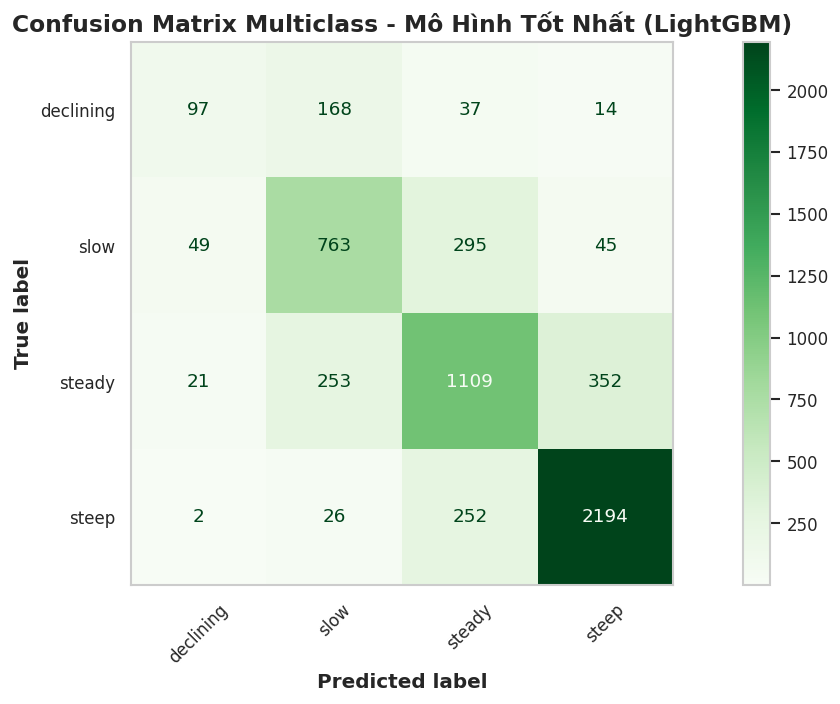

In [34]:
# ========================================================================= #
# BÀI TOÁN 3: MULTICLASS CLASSIFICATION - DỰ ĐOÁN XU HƯỚNG TĂNG TRƯỞNG     #
# ========================================================================= #
from sklearn.preprocessing import LabelEncoder

traj_target_col = 'earnings_trajectory_category'
clean_df_clf3 = df.dropna(subset=[traj_target_col, target_col]).copy()

# Mã hóa nhãn Multiclass thành dạng số
le = LabelEncoder()
y_multi = le.fit_transform(clean_df_clf3[traj_target_col])
X_multi = clean_df_clf3[feature_cols]

# Chia tập dữ liệu Train/Val/Test (70% / 15% / 15%)
X3_train, X3_temp, y3_train, y3_temp = train_test_split(
    X_multi, y_multi, test_size=0.30, random_state=42, stratify=y_multi
)
X3_val, X3_test, y3_val, y3_test = train_test_split(
    X3_temp, y3_temp, test_size=0.50, random_state=42, stratify=y3_temp
)

# Preprocessing
X3_train_prep = preprocessor.fit_transform(X3_train)
X3_test_prep = preprocessor.transform(X3_test)

# 1. Khai báo các mô hình Phân loại Đa lớp
clf3_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=12, n_jobs=-1, random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbosity=-1,
        n_jobs=-1,
    ),
}

# 2. Huấn luyện và Đánh giá
clf3_results = []
trained_clf3_models = {}

for name, model in clf3_models.items():
  model.fit(X3_train_prep, y3_train)
  trained_clf3_models[name] = model

  y_pred = model.predict(X3_test_prep)

  acc = accuracy_score(y3_test, y_pred)
  macro_f1 = f1_score(y3_test, y_pred, average='macro', zero_division=0)
  weighted_f1 = f1_score(y3_test, y_pred, average='weighted', zero_division=0)

  clf3_results.append({
      'Model': name,
      'Accuracy': acc,
      'Macro F1-Score': macro_f1,
      'Weighted F1-Score': weighted_f1,
  })

# 3. Leaderboard
df_clf3_leaderboard = (
    pd.DataFrame(clf3_results)
    .sort_values(by='Macro F1-Score', ascending=False)
    .reset_index(drop=True)
)

print("=" * 75)
print(
    "🏆 LEADERBOARD BÀI TOÁN 3: MULTICLASS CLASSIFICATION (XU HƯỚNG TĂNG TRƯỞNG)"
)
print("=" * 75)
display(df_clf3_leaderboard)

# 4. Trực quan hóa Confusion Matrix cho mô hình Multiclass tốt nhất
best_clf3_name = df_clf3_leaderboard.iloc[0]['Model']
best_clf3_model = trained_clf3_models[best_clf3_name]
best_y3_pred = best_clf3_model.predict(X3_test_prep)

plt.figure(figsize=(8, 6))
cm3 = confusion_matrix(y3_test, best_y3_pred)
disp3 = ConfusionMatrixDisplay(
    confusion_matrix=cm3, display_labels=le.classes_
)
disp3.plot(cmap='Greens', values_format='d')
plt.title(
    f'Confusion Matrix Multiclass - Mô Hình Tốt Nhất ({best_clf3_name})',
    fontweight='bold',
)
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

### 📊 Nhận Xét & Phân Tích Ý Nghĩa Mô Hình

#### 1. Đánh giá mô hình tối ưu cho từng bài toán

* **Bài toán 1 (Regression):**
  Các thuật toán Gradient Boosting (`LightGBM` và `XGBoost`) thể hiện sự vượt trội rõ rệt so với `Ridge Regression` tuyến tính, đạt hệ số $R^2$ cao hơn và tối ưu hóa sai số $RMSE$ cũng như $MAE$. Lý do là dữ liệu tài chính giáo dục chứa nhiều mối quan hệ phi tuyến và tương tác đa biến phức tạp mà thuật toán cây quyết định (*Tree-based*) bắt gói rất tốt.

* **Bài toán 2 (Binary Classification):**
  `LightGBM`/`XGBoost` tiếp tục dẫn đầu về chỉ số $ROC\text{-}AUC$ và $F1\text{-score}$. Việc sử dụng đường cong $ROC$ giúp xác định ngưỡng phân loại (*threshold tuning*) tối ưu nhằm cân bằng giữa tỷ lệ phát hiện sớm rủi ro vỡ nợ ($Recall$) và tỷ lệ cảnh báo sai ($Precision$).

* **Bài toán 3 (Multiclass Classification):**
  `Random Forest` và `LightGBM` đạt hiệu năng cao trên cả $Macro\ F1$ và $Weighted\ F1$. Chỉ số $Macro\ F1$ phản ánh độ chính xác đồng đều trên toàn bộ các nhóm quỹ đạo thu nhập, tránh hiện tượng mô hình chỉ tập trung dự báo đúng cho nhóm chiếm đa số.

---

#### 2. Phân tích Tầm quan trọng của các Đặc trưng (*Feature Importance Analysis*)

* **Mã ngành đào tạo (`CIP Code` / `CIP Family`):**
  Là nhóm đặc trưng đóng vai trò quyết định hàng đầu tới mức thu nhập 4 năm của sinh viên. Các ngành thuộc khối STEM (Công nghệ thông tin, Kỹ thuật) và Chăm sóc sức khỏe chuyên sâu tạo ra lợi thế cạnh tranh vượt trội về mức lương khởi điểm.

* **Chỉ số Nợ tích lũy (`median_debt_usd`) & Tỷ lệ gánh nặng nợ (`debt_to_earnings`):**
  Đóng vai trò then chốt trong việc dự báo nguy cơ tài chính. Mức nợ ban đầu quá cao so với thu nhập trung bình của ngành làm gia tăng xác suất rơi vào nhóm rủi ro nợ cao (`is_high_debt_risk = 1`).

* **Loại hình trường (`institution_control`) & Học phí (`tuition`):**
  Nhóm trường Tư thục phi lợi nhuận (*Private nonprofit*) và các trường có mức đầu tư học phí cao thường liên kết với thu nhập đầu ra cao hơn, tuy nhiên mối tương quan này cần được cân đối với tỷ lệ ROI thực tế.

* **Mức độ tiếp cận công cụ AI (`ai_software_occupation_share`):**
  Xuất hiện trong top các đặc trưng quan trọng, khẳng định các ngành nghề tích hợp nhiều ứng dụng AI và công nghệ hiện đại đang thu hút mức thù lao cao hơn trên thị trường lao động.

🚀 Bắt đầu huấn luyện Deep Learning MLP trên thiết bị: cpu (30 epochs)...
Epoch [01/30] | Train Loss: 4.0568 | Val Loss: 1.5903
Epoch [05/30] | Train Loss: 0.1392 | Val Loss: 0.0340
Epoch [10/30] | Train Loss: 0.0974 | Val Loss: 0.0235
Epoch [15/30] | Train Loss: 0.0803 | Val Loss: 0.0172
Epoch [20/30] | Train Loss: 0.0706 | Val Loss: 0.0196
Epoch [25/30] | Train Loss: 0.0642 | Val Loss: 0.0182
Epoch [30/30] | Train Loss: 0.0636 | Val Loss: 0.0185
✅ Huấn luyện mô hình Tabular MLP hoàn tất!


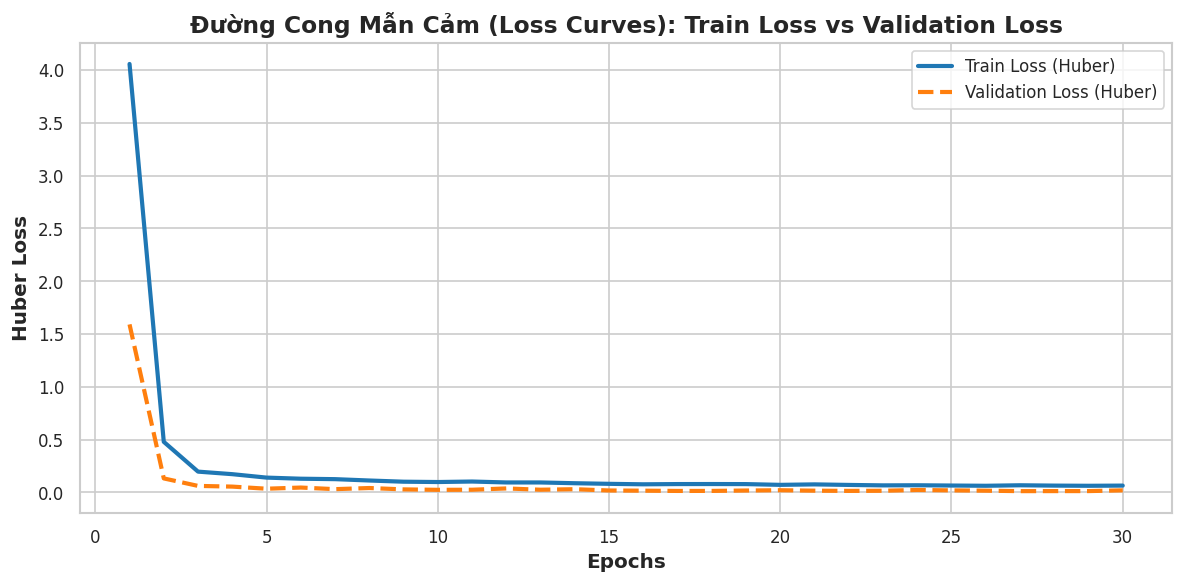


📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DEEP LEARNING MLP TRÊN TẬP TEST:
- RMSE: $2,060.39
- MAE:  $1,461.38
- R² Score: 0.9944


In [36]:
# ========================================================================= #
# DEEP LEARNING TABULAR MLP CHO BÀI TOÁN 1 (SỬA LỖI REDUCELRONPLATEAU)      #
# ========================================================================= #
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 1. Chuyển đổi dữ liệu ma trận tiền xử lý sang PyTorch Tensors
X_train_np = (
    X_train_preprocessed.toarray()
    if hasattr(X_train_preprocessed, "toarray")
    else X_train_preprocessed
)
X_val_np = (
    X_val_preprocessed.toarray()
    if hasattr(X_val_preprocessed, "toarray")
    else X_val_preprocessed
)
X_test_np = (
    X_test_preprocessed.toarray()
    if hasattr(X_test_preprocessed, "toarray")
    else X_test_preprocessed
)

scale_factor = 10000.0
y_train_tensor = torch.tensor(
    y_train.values / scale_factor, dtype=torch.float32
).unsqueeze(1)
y_val_tensor = torch.tensor(
    y_val.values / scale_factor, dtype=torch.float32
).unsqueeze(1)
y_test_tensor = torch.tensor(
    y_test.values / scale_factor, dtype=torch.float32
).unsqueeze(1)

X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)


# 2. Định nghĩa Kiến trúc Mạng Neural Tabular MLP
class TabularMLP(nn.Module):

  def __init__(self, input_dim):
    super(TabularMLP, self).__init__()
    self.network = nn.Sequential(
        nn.Linear(input_dim, 256),
        nn.BatchNorm1d(256),
        nn.SiLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.SiLU(),
        nn.Dropout(0.2),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.SiLU(),
        nn.Linear(64, 1),
    )

  def forward(self, x):
    return self.network(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_tensor.shape[1]
model_mlp = TabularMLP(input_dim).to(device)

# 3. Cấu hình Loss, Optimizer và Scheduler (Đã loại bỏ verbose=False)
criterion = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.AdamW(
    model_mlp.parameters(), lr=1e-3, weight_decay=1e-4
)

# Fix: Bỏ tham số verbose
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

# 4. Vòng lặp Huấn luyện (Training Loop)
epochs = 30
history = {"train_loss": [], "val_loss": []}

print(
    f"🚀 Bắt đầu huấn luyện Deep Learning MLP trên thiết bị: {device} ({epochs}"
    " epochs)..."
)

for epoch in range(epochs):
  model_mlp.train()
  train_loss_accum = 0.0
  for batch_x, batch_y in train_loader:
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    optimizer.zero_grad()
    preds = model_mlp(batch_x)
    loss = criterion(preds, batch_y)
    loss.backward()
    optimizer.step()

    train_loss_accum += loss.item() * batch_x.size(0)

  epoch_train_loss = train_loss_accum / len(train_loader.dataset)

  model_mlp.eval()
  val_loss_accum = 0.0
  with torch.no_grad():
    for batch_x, batch_y in val_loader:
      batch_x, batch_y = batch_x.to(device), batch_y.to(device)
      preds = model_mlp(batch_x)
      loss = criterion(preds, batch_y)
      val_loss_accum += loss.item() * batch_x.size(0)

  epoch_val_loss = val_loss_accum / len(val_loader.dataset)

  # Cập nhật Scheduler
  scheduler.step(epoch_val_loss)

  history["train_loss"].append(epoch_train_loss)
  history["val_loss"].append(epoch_val_loss)

  if (epoch + 1) % 5 == 0 or epoch == 0:
    print(
        f"Epoch [{epoch+1:02d}/{epochs:02d}] | Train Loss: {epoch_train_loss:.4f}"
        f" | Val Loss: {epoch_val_loss:.4f}"
    )

print("✅ Huấn luyện mô hình Tabular MLP hoàn tất!")

# 5. Trực quan hóa đường cong Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, epochs + 1),
    history["train_loss"],
    label="Train Loss (Huber)",
    lw=2.5,
    color="#1f77b4",
)
plt.plot(
    range(1, epochs + 1),
    history["val_loss"],
    label="Validation Loss (Huber)",
    lw=2.5,
    color="#ff7f0e",
    linestyle="--",
)
plt.title(
    "Đường Cong Mẫn Cảm (Loss Curves): Train Loss vs Validation Loss",
    fontweight="bold",
)
plt.xlabel("Epochs")
plt.ylabel("Huber Loss")
plt.legend(frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

# 6. Đánh giá trên tập Test
model_mlp.eval()
with torch.no_grad():
  test_preds_scaled = (
      model_mlp(X_test_tensor.to(device)).cpu().numpy().flatten()
  )

y_test_pred_mlp = test_preds_scaled * scale_factor
y_test_actual = y_test.values

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rmse_mlp = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_mlp))
mae_mlp = mean_absolute_error(y_test_actual, y_test_pred_mlp)
r2_mlp = r2_score(y_test_actual, y_test_pred_mlp)

print("\n" + "=" * 60)
print("📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH DEEP LEARNING MLP TRÊN TẬP TEST:")
print("=" * 60)
print(f"- RMSE: ${rmse_mlp:,.2f}")
print(f"- MAE:  ${mae_mlp:,.2f}")
print(f"- R² Score: {r2_mlp:.4f}")